<a href="https://colab.research.google.com/github/gulzar999/TF-Transcrptional-factors-/blob/main/TFs_tokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install requests pandas

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout
import json

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
df = pd.read_csv('UniProt_Results.csv')
df = df.dropna(subset=['Sequence'])
# To keep training fast, we will use a subset of unique sequences
all_sequences = "".join(df['Sequence'].unique()[:500]) # Using first 500 unique TFs

# Mapping
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
char_to_int = {ch: i for i, ch in enumerate(AMINO_ACIDS)}
int_to_char = {i: ch for i, ch in enumerate(AMINO_ACIDS)}

# Create sliding windows
maxlen = 40  # Length of the input fragment
step = 3     # How many characters to skip between windows
sentences = []
next_chars = []

print("Extracting fragments...")
for i in range(0, len(all_sequences) - maxlen, step):
    segment = all_sequences[i : i + maxlen]
    next_c = all_sequences[i + maxlen]
    # Only keep segments with standard amino acids
    if all(c in char_to_int for c in segment) and next_c in char_to_int:
        sentences.append([char_to_int[c] for c in segment])
        next_chars.append(char_to_int[next_c])

X = np.array(sentences)
y = np.array(next_chars)

print(f"Total training patterns: {len(X)}")

# ==========================================
# 2. DEFINE THE RNN (LSTM) MODEL
# ==========================================
model = Sequential([
    # Embedding turns integers into dense vectors
    Embedding(input_dim=len(AMINO_ACIDS), output_dim=64, input_length=maxlen),
    # LSTM is a type of RNN that remembers long patterns
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(128),
    # Output layer: 20 neurons (one for each Amino Acid)
    Dense(len(AMINO_ACIDS), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

# ==========================================
# 3. TRAINING
# ==========================================
print("Starting training (this may take a few minutes)...")
model.fit(X, y, batch_size=128, epochs=10) # 10 epochs for demonstration

# ==========================================
# 4. SEQUENCE GENERATION FUNCTION
# ==========================================
def generate_tf_sequence(model, seed_seq, length=100, temperature=1.0):
    """
    Generates a new sequence starting from a seed.
    'temperature' controls randomness:
    - Low (< 1.0) = conservative/predictable
    - High (> 1.0) = creative/random
    """
    generated = seed_seq

    for _ in range(length):
        # Format the current sequence for the model
        x_input = [char_to_int[c] for c in generated[-maxlen:]]
        x_input = np.reshape(x_input, (1, maxlen))

        # Predict the next amino acid
        preds = model.predict(x_input, verbose=0)[0]

        # Apply temperature scaling for variety
        preds = np.log(preds) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # Sample the next character
        next_index = np.random.choice(len(AMINO_ACIDS), p=preds)
        next_char = int_to_char[next_index]

        generated += next_char

    return generated

# ==========================================
# 5. GENERATE A RANDOM SEQUENCE
# ==========================================
# Grab a random starting seed from your data
start_index = np.random.randint(0, len(all_sequences) - maxlen - 1)
seed = all_sequences[start_index : start_index + maxlen]

print("\n--- Generating New Sequence ---")
print(f"Seed: {seed}")
new_sequence = generate_tf_sequence(model, seed, length=50)
print(f"Generated: {new_sequence}")

Extracting fragments...
Total training patterns: 105564


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Starting training (this may take a few minutes)...
Epoch 1/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 2.8280
Epoch 2/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 2.8036
Epoch 3/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 2.7874
Epoch 4/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 2.7732
Epoch 5/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 2.7575
Epoch 6/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 2.7409
Epoch 7/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 2.7243
Epoch 8/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 2.7049
Epoch 9/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 2.6827
Epoch 10/10
825/825 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 2.6584

--- Generating New Sequence ---
Seed: KENGLEPHLVKKVLEKVSETFGYRRLEDFMASHLDYLVLE
Generated: KENGLEPHLVKKVLEKVSETFGYRRLEDFMASHLDYLVLEFTISGPAVTKGAFHTGNRRFFEDTVDLELKRVKNKEALKQETSQDLVKKS


Extracting fragments...
Total training patterns: 166535
Starting training...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1041/1041 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.1178 - loss: 2.8310 - val_accuracy: 0.1214 - val_loss: 2.8088
Epoch 2/15
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.1302 - loss: 2.8035 - val_accuracy: 0.1371 - val_loss: 2.7814
Epoch 3/15
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.1402 - loss: 2.7802 - val_accuracy: 0.1478 - val_loss: 2.7494
Epoch 4/15
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.1470 - loss: 2.7573 - val_accuracy: 0.1517 - val_loss: 2.7326
Epoch 5/15
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.1535 - loss: 2.7371 - val_accuracy: 0.1513 - val_loss: 2.7358
Epoch 6/15
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.1616 - loss: 2.7106 - val_accuracy: 0.1555 - val_loss: 2.7303
Epoch 7/15
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.1745 - loss: 2.6689 - val_accuracy: 0.1523 - val_loss: 2.7394
Epoch 8/15
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.1916 - loss: 2.61

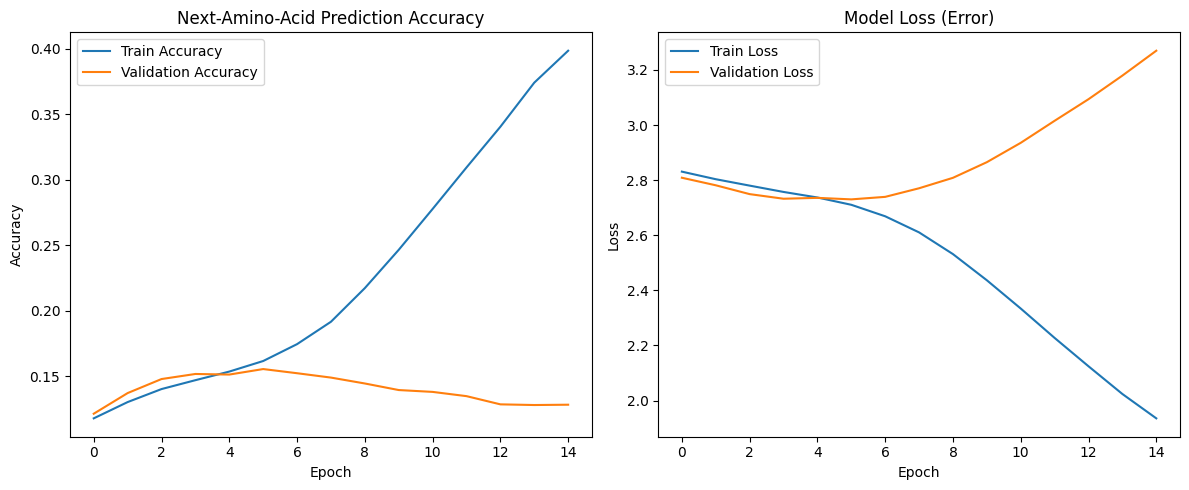


--- Generating New Sequence ---
Seed: PLAADTSYYQGVYSRPIMNSSMAPAADMTSLPLGVKVEDS
Generated: PLAADTSYYQGVYSRPIMNSSMAPAADMTSLPLGVKVEDSYGFTSTTAFHIENLNGGTTQPSKSCDVPAMESEEEEKLSEEEDLQPSSEKKNKNKKKKSR
Is this a copy from the dataset?: No, this is a NOVEL sequence!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, BatchNormalization
import json
import time

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
df = pd.read_csv('UniProt_Results.csv')
df = df.dropna(subset=['Sequence'])
# Using unique sequences to ensure the model learns diverse patterns
unique_sequences = df['Sequence'].unique().tolist()
# Combine a subset for training (adjust [:1000] based on your Colab RAM)
all_text = "".join(unique_sequences[:800])

# Mapping
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
char_to_int = {ch: i for i, ch in enumerate(AMINO_ACIDS)}
int_to_char = {i: ch for i, ch in enumerate(AMINO_ACIDS)}

# Create sliding windows
maxlen = 40  # Context window
step = 3     # Skip steps to create more diverse samples
sentences = []
next_chars = []

print("Extracting fragments...")
for i in range(0, len(all_text) - maxlen, step):
    segment = all_text[i : i + maxlen]
    next_c = all_text[i + maxlen]
    if all(c in char_to_int for c in segment) and next_c in char_to_int:
        sentences.append([char_to_int[c] for c in segment])
        next_chars.append(char_to_int[next_c])

X = np.array(sentences)
y = np.array(next_chars)
print(f"Total training patterns: {len(X)}")

# ==========================================
# 2. DEFINE THE MODEL WITH ACCURACY
# ==========================================
model = Sequential([
    Embedding(input_dim=len(AMINO_ACIDS), output_dim=64, input_length=maxlen),
    LSTM(256, return_sequences=True),
    Dropout(0.2),
    LSTM(256),
    Dense(len(AMINO_ACIDS), activation='softmax')
])

# We use sparse_categorical_crossentropy because 'y' are integers (0-19)
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# ==========================================
# 3. TRAINING WITH VALIDATION SPLIT
# ==========================================
print("Starting training...")
# validation_split=0.2 means 20% of data is used for testing/validation
history = model.fit(X, y, batch_size=128, epochs=15, validation_split=0.2)

# ==========================================
# 4. PLOT TRAINING RESULTS
# ==========================================
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Next-Amino-Acid Prediction Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Error)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 5. GENERATION & NOVELTY CHECK
# ==========================================
def generate_and_check(model, seed_seq, length=60, temp=1.0):
    generated = seed_seq
    for _ in range(length):
        x_input = np.reshape([char_to_int[c] for c in generated[-maxlen:]], (1, maxlen))
        preds = model.predict(x_input, verbose=0)[0]

        # Temperature sampling
        preds = np.log(preds) / temp
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        next_index = np.random.choice(len(AMINO_ACIDS), p=preds)
        generated += int_to_char[next_index]

    # Check if this sequence is a duplicate of any existing sequence
    is_duplicate = any(generated in s for s in unique_sequences)

    return generated, is_duplicate

# Pick a random seed
start_idx = np.random.randint(0, len(all_text) - maxlen - 1)
seed = all_text[start_idx : start_idx + maxlen]

print("\n--- Generating New Sequence ---")
new_seq, duplicate_found = generate_and_check(model, seed)

print(f"Seed: {seed}")
print(f"Generated: {new_seq}")
print(f"Is this a copy from the dataset?: {'Yes' if duplicate_found else 'No, this is a NOVEL sequence!'}")

STEP 1: Loading data
  Raw rows        : 16,634
  Columns         : ['UniprotID.TF', 'Sequence']

STEP 2: Removing nulls & duplicates
  Removed nulls   : 8
  Removed dups    : 15,788
  Unique TFs      : 838

STEP 3: Length filtering & AA validation
  Removed short / non-standard: 0
  Remaining       : 838
  Length  min/mean/max: 73 / 639 / 5537

STEP 4: Encoding sequences
  Building integer-encoded matrix …
  Building one-hot matrix …
  Building Atchley (physico-chemical) matrix …
  Integer shape   : (838, 1024)
  One-hot shape   : (838, 1024, 20)
  Atchley shape   : (838, 1024, 5)

STEP 5: Train / Val / Test split
  Train : 586  (69.9%)
  Val   : 126   (15.0%)
  Test  : 126   (15.0%)

STEP 6: Saving outputs
  Saved: preprocessed_data/sequences_clean.csv
  Saved: preprocessed_data/integer_train.npy  shape=(586, 1024)
  Saved: preprocessed_data/integer_val.npy  shape=(126, 1024)
  Saved: preprocessed_data/integer_test.npy  shape=(126, 1024)
  Saved: preprocessed_data/onehot_train.npy  s

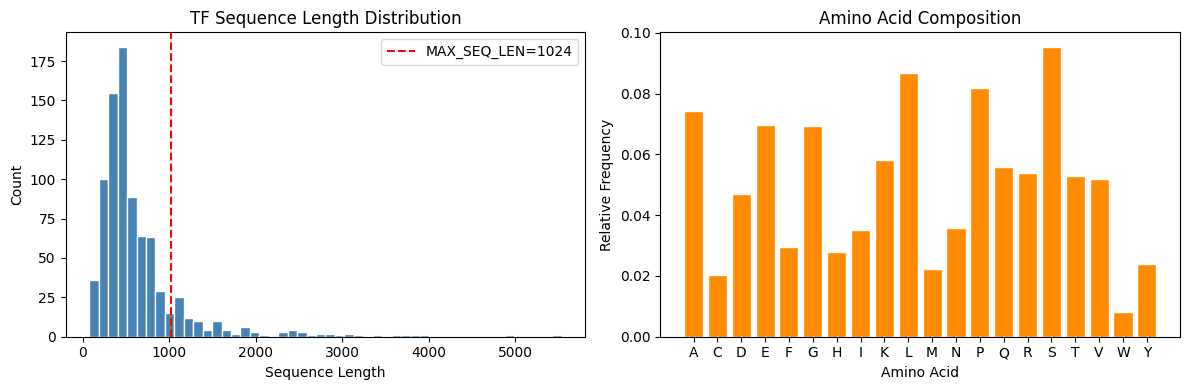

In [ ]:
"""
Transcription Factor Sequence Preprocessing Pipeline
======================================================
Dataset: 16,634 rows → 838 unique TF protein sequences
Task   : Prepare data for deep learning (CNN / LSTM / Transformer)

Steps:
  1. Load & Validate
  2. Remove Nulls & Duplicates
  3. Filter by Sequence Length
  4. Encode Sequences  (one-hot, integer, physico-chemical)
  5. Pad / Truncate to Fixed Length
  6. Train / Val / Test Split
  7. Save Outputs
"""

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# CONFIG  (change these to suit your task)
# ─────────────────────────────────────────────
INPUT_CSV      = "UniProt_Results.csv"   # path to your input file
OUTPUT_DIR     = "preprocessed_data"
MAX_SEQ_LEN    = 1024   # 95th percentile ≈ 1124; 1024 is GPU-friendly
MIN_SEQ_LEN    = 50     # drop extremely short fragments
PAD_TOKEN      = 0      # integer used for padding
TEST_SIZE      = 0.15
VAL_SIZE       = 0.15
RANDOM_STATE   = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Standard 20 amino acids (alphabetical order → stable mapping)
STANDARD_AAS = list("ACDEFGHIKLMNPQRSTVWY")
AA2IDX       = {aa: i + 1 for i, aa in enumerate(STANDARD_AAS)}  # 1-based; 0 = pad
VOCAB_SIZE   = len(STANDARD_AAS) + 1  # 21

# Atchley factors (5 physico-chemical descriptors per AA)
# Source: Atchley et al. (2005) PNAS
ATCHLEY = {
    'A': [-0.591, -1.302, -0.733,  1.570, -0.146],
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],
    'E': [ 1.357, -1.453,  1.477,  0.113, -0.837],
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],
    'G': [-0.384,  1.652,  1.330,  1.045,  2.064],
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],
    'Q': [ 0.931, -0.179, -3.005, -0.503, -1.853],
    'R': [ 1.538, -0.055,  1.502,  0.440,  2.897],
    'S': [-0.228,  1.399, -4.760,  0.670, -2.647],
    'T': [-0.032,  0.326,  2.213,  0.908,  1.313],
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512],
}


# ═══════════════════════════════════════════════
# STEP 1 — Load & Validate
# ═══════════════════════════════════════════════
print("=" * 55)
print("STEP 1: Loading data")
df = pd.read_csv(INPUT_CSV)
print(f"  Raw rows        : {len(df):,}")
print(f"  Columns         : {df.columns.tolist()}")

# Validate columns
assert 'Sequence' in df.columns,       "Missing 'Sequence' column"
assert 'UniprotID.TF' in df.columns,   "Missing 'UniprotID.TF' column"


# ═══════════════════════════════════════════════
# STEP 2 — Remove Nulls & Exact Duplicates
# ═══════════════════════════════════════════════
print("\nSTEP 2: Removing nulls & duplicates")
before = len(df)
df = df.dropna(subset=['Sequence', 'UniprotID.TF'])
print(f"  Removed nulls   : {before - len(df):,}")

before = len(df)
df = df.drop_duplicates(subset=['UniprotID.TF'])   # keep first isoform per TF
print(f"  Removed dups    : {before - len(df):,}")
print(f"  Unique TFs      : {len(df):,}")


# ═══════════════════════════════════════════════
# STEP 3 — Filter by Length & Validate AAs
# ═══════════════════════════════════════════════
print("\nSTEP 3: Length filtering & AA validation")
standard_set = set(STANDARD_AAS)

def is_valid(seq):
    return all(c in standard_set for c in seq)

df['seq_len'] = df['Sequence'].str.len()
before = len(df)

df = df[df['seq_len'] >= MIN_SEQ_LEN]
df = df[df['Sequence'].apply(is_valid)]
print(f"  Removed short / non-standard: {before - len(df):,}")
print(f"  Remaining       : {len(df):,}")
print(f"  Length  min/mean/max: "
      f"{df['seq_len'].min()} / {df['seq_len'].mean():.0f} / {df['seq_len'].max()}")


# ═══════════════════════════════════════════════
# STEP 4 — Sequence Encoding
# ═══════════════════════════════════════════════
print("\nSTEP 4: Encoding sequences")

# --- 4a. Integer encoding (for Embedding layers) ---
def integer_encode(seq, max_len):
    enc = [AA2IDX.get(aa, 0) for aa in seq[:max_len]]
    enc += [PAD_TOKEN] * (max_len - len(enc))
    return enc

# --- 4b. One-Hot encoding (for CNN / direct input) ---
def onehot_encode(seq, max_len):
    matrix = np.zeros((max_len, len(STANDARD_AAS)), dtype=np.float32)
    for i, aa in enumerate(seq[:max_len]):
        if aa in AA2IDX:
            matrix[i, AA2IDX[aa] - 1] = 1.0
    return matrix

# --- 4c. Physico-chemical (Atchley) encoding ---
def atchley_encode(seq, max_len):
    matrix = np.zeros((max_len, 5), dtype=np.float32)
    for i, aa in enumerate(seq[:max_len]):
        if aa in ATCHLEY:
            matrix[i] = ATCHLEY[aa]
    return matrix

sequences = df['Sequence'].tolist()
ids       = df['UniprotID.TF'].tolist()

print("  Building integer-encoded matrix …")
int_matrix = np.array(
    [integer_encode(s, MAX_SEQ_LEN) for s in sequences], dtype=np.int32
)

print("  Building one-hot matrix …")
onehot_matrix = np.array(
    [onehot_encode(s, MAX_SEQ_LEN) for s in sequences], dtype=np.float32
)

print("  Building Atchley (physico-chemical) matrix …")
atchley_matrix = np.array(
    [atchley_encode(s, MAX_SEQ_LEN) for s in sequences], dtype=np.float32
)

print(f"  Integer shape   : {int_matrix.shape}")     # (N, MAX_SEQ_LEN)
print(f"  One-hot shape   : {onehot_matrix.shape}")  # (N, MAX_SEQ_LEN, 20)
print(f"  Atchley shape   : {atchley_matrix.shape}") # (N, MAX_SEQ_LEN, 5)


# ═══════════════════════════════════════════════
# STEP 5 — Train / Val / Test Split
# ═══════════════════════════════════════════════
print("\nSTEP 5: Train / Val / Test split")
n = len(sequences)
indices = np.arange(n)

idx_train, idx_test = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
idx_train, idx_val = train_test_split(
    idx_train, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE
)

print(f"  Train : {len(idx_train):,}  ({100*len(idx_train)/n:.1f}%)")
print(f"  Val   : {len(idx_val):,}   ({100*len(idx_val)/n:.1f}%)")
print(f"  Test  : {len(idx_test):,}   ({100*len(idx_test)/n:.1f}%)")

splits = {
    'train': idx_train,
    'val':   idx_val,
    'test':  idx_test,
}


# ═══════════════════════════════════════════════
# STEP 6 — Save Outputs
# ═══════════════════════════════════════════════
print("\nSTEP 6: Saving outputs")

# Save clean metadata CSV
clean_df = df[['UniprotID.TF', 'Sequence', 'seq_len']].reset_index(drop=True)
clean_df['split'] = ''
for split_name, idxs in splits.items():
    clean_df.loc[idxs, 'split'] = split_name
clean_df.to_csv(f"{OUTPUT_DIR}/sequences_clean.csv", index=False)
print(f"  Saved: {OUTPUT_DIR}/sequences_clean.csv")

# Save NumPy arrays for each encoding × split
for enc_name, matrix in [('integer', int_matrix),
                          ('onehot',  onehot_matrix),
                          ('atchley', atchley_matrix)]:
    for split_name, idxs in splits.items():
        path = f"{OUTPUT_DIR}/{enc_name}_{split_name}.npy"
        np.save(path, matrix[idxs])
        print(f"  Saved: {path}  shape={matrix[idxs].shape}")

# Save amino-acid mapping
import json
with open(f"{OUTPUT_DIR}/aa2idx.json", "w") as f:
    json.dump(AA2IDX, f, indent=2)
print(f"  Saved: {OUTPUT_DIR}/aa2idx.json")


# ═══════════════════════════════════════════════
# STEP 7 — EDA Plot (sequence length distribution)
# ═══════════════════════════════════════════════
print("\nSTEP 7: Generating EDA plot")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['seq_len'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(MAX_SEQ_LEN, color='red', linestyle='--', label=f'MAX_SEQ_LEN={MAX_SEQ_LEN}')
axes[0].set_xlabel("Sequence Length")
axes[0].set_ylabel("Count")
axes[0].set_title("TF Sequence Length Distribution")
axes[0].legend()

# AA frequency
aa_counts = {}
for seq in df['Sequence']:
    for aa in seq:
        aa_counts[aa] = aa_counts.get(aa, 0) + 1
total = sum(aa_counts.values())
aas_sorted = sorted(aa_counts.keys())
freqs = [aa_counts[a] / total for a in aas_sorted]
axes[1].bar(aas_sorted, freqs, color='darkorange', edgecolor='white')
axes[1].set_xlabel("Amino Acid")
axes[1].set_ylabel("Relative Frequency")
axes[1].set_title("Amino Acid Composition")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_plots.png", dpi=150)
print(f"  Saved: {OUTPUT_DIR}/eda_plots.png")

print("\n✅  Preprocessing complete!")
print(f"    All outputs are in → ./{OUTPUT_DIR}/")
print("""
─────────────────────────────────────────
HOW TO USE IN YOUR MODEL
─────────────────────────────────────────
import numpy as np

# For CNN / Transformer (one-hot):
X_train = np.load('preprocessed_data/onehot_train.npy')  # (N, 1024, 20)
X_val   = np.load('preprocessed_data/onehot_val.npy')

# For LSTM with Embedding layer (integer):
X_train = np.load('preprocessed_data/integer_train.npy') # (N, 1024)

# For physico-chemical features:
X_train = np.load('preprocessed_data/atchley_train.npy') # (N, 1024, 5)
─────────────────────────────────────────
""")

In [ ]:
"""
STEP 1 — Fetch TF Family Labels from UniProt
=============================================
Run this script FIRST on your local machine.
It queries UniProt REST API for each TF ID and extracts:
  - Protein family (from SIMILARITY comment)
  - TF class keyword (zinc finger, homeodomain, etc.)

Output: preprocessed_data/tf_labels.csv
"""

import os
import time
import json
import requests
import pandas as pd
from collections import Counter

INPUT_CSV  = "UniProt_Results.csv"
OUTPUT_DIR = "preprocessed_data"
OUTPUT_CSV = f"{OUTPUT_DIR}/tf_labels.csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Known TF family keywords from UniProt ──────────────────────────
TF_FAMILY_KEYWORDS = [
    "Zinc-finger", "Homeodomain", "bHLH", "bZIP", "Winged helix-turn-helix",
    "Fork head", "ETS domain", "Nuclear receptor", "MADS-box", "WRKY",
    "RHD domain", "C2H2-type", "C4-type", "RING-type", "Leucine-rich",
    "T-box", "GATA-type", "Paired box", "HMG box", "SAZ",
]

def get_tf_info(uniprot_id, retries=3):
    """Fetch family and keyword info for one UniProt ID."""
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=15)
            if r.status_code == 200:
                data = r.json()

                # 1. Extract family from SIMILARITY comment
                family = None
                for c in data.get("comments", []):
                    if c.get("commentType") == "SIMILARITY":
                        texts = c.get("texts", [])
                        if texts:
                            family = texts[0].get("value", "")
                            break

                # 2. Extract TF-related keywords
                keywords = [k["name"] for k in data.get("keywords", [])]
                tf_keywords = [k for k in keywords
                               if any(tf.lower() in k.lower() for tf in TF_FAMILY_KEYWORDS)]

                # 3. Gene name
                gene = None
                genes = data.get("genes", [])
                if genes:
                    gene = genes[0].get("geneName", {}).get("value", None)

                # 4. Organism
                organism = data.get("organism", {}).get("scientificName", "")

                return {
                    "UniprotID": uniprot_id,
                    "gene_name": gene,
                    "organism": organism,
                    "family_raw": family,
                    "tf_keywords": "; ".join(tf_keywords) if tf_keywords else None,
                    "all_keywords": "; ".join(keywords),
                }
            elif r.status_code == 404:
                return {"UniprotID": uniprot_id, "error": "not_found"}
        except Exception as e:
            print(f"  [attempt {attempt+1}] Error for {uniprot_id}: {e}")
            time.sleep(2 ** attempt)
    return {"UniprotID": uniprot_id, "error": "failed"}


def assign_tf_class(row):
    """
    Assign a clean TF class label from raw family/keyword text.
    Priority: tf_keywords → family_raw pattern match → 'Unknown'
    """
    text = " ".join(filter(None, [
        str(row.get("tf_keywords", "") or ""),
        str(row.get("family_raw", "") or ""),
        str(row.get("all_keywords", "") or ""),
    ])).lower()

    CLASS_MAP = [
        ("zinc finger",      "Zinc_Finger"),
        ("c2h2",             "Zinc_Finger"),
        ("c4-type",          "Zinc_Finger"),
        ("homeodomain",      "Homeodomain"),
        ("homeobox",         "Homeodomain"),
        ("bhlh",             "bHLH"),
        ("helix-loop-helix", "bHLH"),
        ("bzip",             "bZIP"),
        ("leucine zipper",   "bZIP"),
        ("nuclear receptor", "Nuclear_Receptor"),
        ("ets domain",       "ETS"),
        ("fork head",        "Forkhead"),
        ("forkhead",         "Forkhead"),
        ("mads",             "MADS_box"),
        ("t-box",            "T_box"),
        ("gata",             "GATA"),
        ("hmg",              "HMG"),
        ("paired box",       "PAX"),
        ("wrky",             "WRKY"),
        ("runt",             "Runt"),
        ("stat",             "STAT"),
        ("nf-kb",            "NFkB"),
        ("rel domain",       "NFkB"),
        ("p53",              "p53_family"),
        ("sox",              "HMG"),
        ("myb",              "MYB"),
    ]

    for pattern, label in CLASS_MAP:
        if pattern in text:
            return label
    return "Other_TF"


# ── Main fetch loop ────────────────────────────────────────────────
df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=["Sequence", "UniprotID.TF"]).drop_duplicates(subset=["UniprotID.TF"])
ids = df["UniprotID.TF"].tolist()

print(f"Fetching labels for {len(ids)} TF sequences from UniProt...")
print("This may take ~5-10 minutes. Progress is saved every 50 IDs.\n")

results = []
for i, uid in enumerate(ids):
    info = get_tf_info(uid)
    results.append(info)

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{len(ids)}] {uid} → {info.get('tf_keywords', info.get('error',''))}")

    if (i + 1) % 50 == 0:
        # Save checkpoint
        pd.DataFrame(results).to_csv(OUTPUT_CSV + ".checkpoint", index=False)

    time.sleep(0.2)   # be polite to UniProt API

# ── Post-process ──────────────────────────────────────────────────
label_df = pd.DataFrame(results)
label_df["tf_class"] = label_df.apply(assign_tf_class, axis=1)

# Merge back with sequences
merged = df.merge(label_df, left_on="UniprotID.TF", right_on="UniprotID", how="left")

# ── Summary ───────────────────────────────────────────────────────
print("\n" + "="*50)
print("TF CLASS DISTRIBUTION:")
print("="*50)
class_counts = merged["tf_class"].value_counts()
print(class_counts.to_string())
print(f"\nTotal labeled   : {merged['tf_class'].notna().sum()}")
print(f"Unknown / Other : {(merged['tf_class'] == 'Other_TF').sum()}")

# Save
merged[["UniprotID.TF", "Sequence", "gene_name", "organism",
        "tf_class", "family_raw", "tf_keywords"]].to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ Labels saved to: {OUTPUT_CSV}")
print("\nNext step → run:  python step2_train_cnn.py")

Fetching labels for 838 TF sequences from UniProt...
This may take ~5-10 minutes. Progress is saved every 50 IDs.

  [10/838] P16415 → Zinc-finger
  [20/838] Q92922 → None
  [30/838] P15336 → Zinc-finger
  [40/838] P11161 → Zinc-finger
  [50/838] Q07869 → Zinc-finger
  [60/838] P19544 → Zinc-finger
  [70/838] O75030 → None
  [80/838] Q14209 → None
  [90/838] Q06330 → None
  [100/838] P32519 → None
  [110/838] P20823 → None
  [120/838] O43474 → Zinc-finger
  [130/838] P48431 → None
  [140/838] P67809 → None
  [150/838] P43268 → None
  [160/838] Q16621 → None
  [170/838] P47902 → None
  [180/838] P36956 → None
  [190/838] Q16649 → None
  [200/838] Q99717 → None
  [210/838] O14813 → None
  [220/838] P28360 → None
  [230/838] Q86SK9 → None
  [240/838] Q92585 → None
  [250/838] P17096 → None
  [260/838] P78545 → None
  [270/838] Q92731 → Zinc-finger
  [280/838] O95948 → None
  [290/838] Q16633 → None
  [300/838] P49736 → Zinc-finger
  [310/838] P20749 → None
  [320/838] Q16656 → None
  [330

Device: cuda

── Loading data ──
  Sequences: 838
  Train: 712   Val: 126

  Model parameters: 1,137,623

── Training ──
  Epoch 001/100  loss=2.8266  acc=0.146  val_loss=2.7101  val_acc=0.187
  Epoch 010/100  loss=2.5852  acc=0.229  val_loss=2.6159  val_acc=0.215
  Epoch 020/100  loss=2.5499  acc=0.237  val_loss=2.5985  val_acc=0.222
  Epoch 030/100  loss=2.5313  acc=0.244  val_loss=2.5756  val_acc=0.225
  Epoch 040/100  loss=2.5123  acc=0.250  val_loss=2.5668  val_acc=0.231
  Epoch 050/100  loss=2.5009  acc=0.252  val_loss=2.5634  val_acc=0.236
  Epoch 060/100  loss=2.4784  acc=0.258  val_loss=2.5816  val_acc=0.226
  Epoch 070/100  loss=2.4624  acc=0.264  val_loss=2.5303  val_acc=0.246
  Epoch 080/100  loss=2.4571  acc=0.269  val_loss=2.5639  val_acc=0.233
  Epoch 090/100  loss=2.4506  acc=0.266  val_loss=2.5384  val_acc=0.240
  Epoch 100/100  loss=2.4497  acc=0.266  val_loss=2.5563  val_acc=0.233

  Best val loss: 2.5303

── Extracting sequence embeddings ──
  Embedding matrix shape

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Saved: ssl_results/umap_embeddings.png
  Saved: ssl_results/embeddings_with_metadata.csv

╔══════════════════════════════════════════════════════╗
║  Self-supervised training complete!
║                                                       ║
║  What you now have:                                   ║
║  • best_encoder.pt          → trained CNN weights     ║
║  • sequence_embeddings.npy  → (838, 256) vectors      ║
║  • training_curves.png      → loss & accuracy plots   ║
║  • umap_embeddings.png      → 2D visualization
║  • embeddings_with_metadata.csv → for analysis
║
║  Next steps:
║  1. Load the embeddings and run clustering (K-Means)
║  2. Add your own labels later → fine-tune the encoder
║  3. Use embeddings for similarity search between TFs
╚══════════════════════════════════════════════════════╝



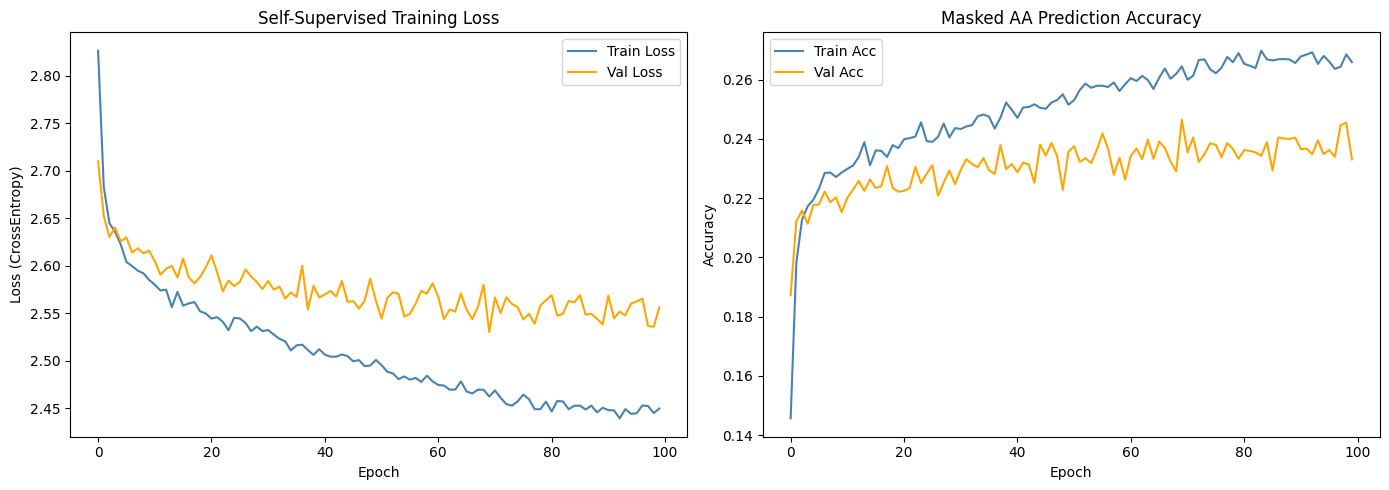

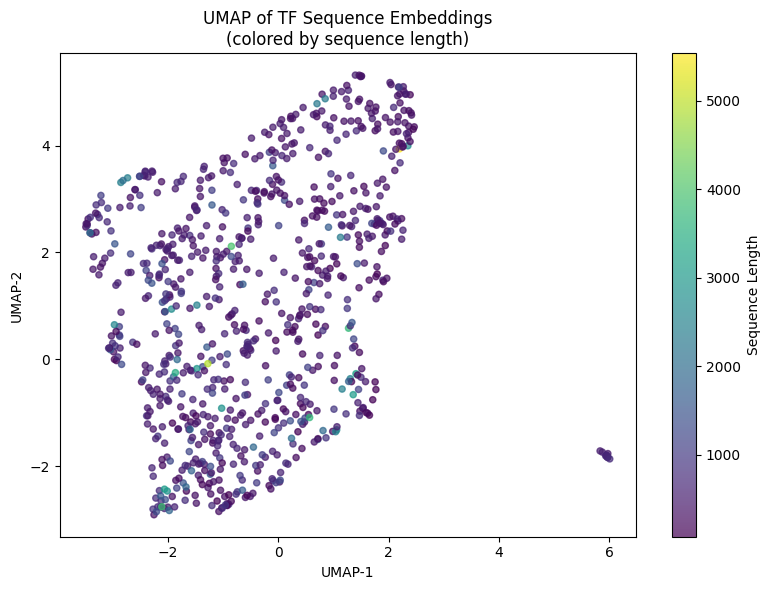

In [ ]:
"""
Self-Supervised CNN — Masked Amino Acid Prediction
=====================================================
No labels needed. The model learns by:
  1. Randomly masking 15% of amino acids in each sequence
  2. Trying to predict the original amino acid at masked positions
  3. This forces the CNN to learn biological patterns & motifs

After training the encoder captures rich sequence representations
that can be used for clustering, visualization, or fine-tuning.

Usage:
  pip install torch scikit-learn matplotlib seaborn umap-learn
  python self_supervised_cnn.py
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_CSV    = "UniProt_Results.csv"
OUTPUT_DIR   = "ssl_results"
MAX_SEQ_LEN  = 1024
MASK_RATIO   = 0.15     # mask 15% of amino acids
BATCH_SIZE   = 16       # small batch since dataset is small
EPOCHS       = 100
LR           = 5e-4
EMBED_DIM    = 64       # learned embedding size per amino acid
DROPOUT      = 0.3
RANDOM_STATE = 42
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Device: {DEVICE}")

# ─────────────────────────────────────────────
# AMINO ACID VOCABULARY
# ─────────────────────────────────────────────
STANDARD_AAS = list("ACDEFGHIKLMNPQRSTVWY")
PAD_TOKEN    = 0   # padding
MASK_TOKEN   = 21  # [MASK]
AA2IDX = {aa: i + 1 for i, aa in enumerate(STANDARD_AAS)}  # 1–20
VOCAB_SIZE = 23    # 0=pad, 1-20=AAs, 21=mask, 22=unused buffer

def integer_encode(seq, max_len):
    """Encode sequence as integer indices, pad to max_len."""
    enc = [AA2IDX.get(aa, PAD_TOKEN) for aa in seq[:max_len]]
    enc += [PAD_TOKEN] * (max_len - len(enc))
    return enc


# ─────────────────────────────────────────────
# STEP 1 — Load & Clean Data
# ─────────────────────────────────────────────
print("\n── Loading data ──")
df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=["Sequence", "UniprotID.TF"])
df = df.drop_duplicates(subset=["UniprotID.TF"]).reset_index(drop=True)

standard_set = set(STANDARD_AAS)
df = df[df["Sequence"].apply(lambda s: all(c in standard_set for c in s))]
df = df[df["Sequence"].str.len() >= 50].reset_index(drop=True)

print(f"  Sequences: {len(df)}")

sequences = df["Sequence"].tolist()
ids       = df["UniprotID.TF"].tolist()


# ─────────────────────────────────────────────
# STEP 2 — Dataset with Dynamic Masking
# ─────────────────────────────────────────────
class MaskedTFDataset(Dataset):
    """
    Each call to __getitem__ re-masks randomly — so every epoch
    the model sees different masks. This acts as data augmentation.

    Returns:
      masked_seq  : (max_len,)  integer-encoded with some positions = MASK_TOKEN
      target_seq  : (max_len,)  original integer-encoded sequence
      mask_pos    : (max_len,)  boolean — True where masked
    """
    def __init__(self, sequences, max_len, mask_ratio):
        self.sequences  = sequences
        self.max_len    = max_len
        self.mask_ratio = mask_ratio
        self.encoded    = [integer_encode(s, max_len) for s in sequences]

    def __len__(self):
        return len(self.encoded)

    def __getitem__(self, idx):
        original   = np.array(self.encoded[idx], dtype=np.int64)
        masked     = original.copy()
        mask_pos   = np.zeros(self.max_len, dtype=bool)

        # Find non-padding positions
        non_pad = np.where(original != PAD_TOKEN)[0]
        n_mask  = max(1, int(len(non_pad) * self.mask_ratio))

        # Randomly choose positions to mask
        chosen = np.random.choice(non_pad, n_mask, replace=False)
        mask_pos[chosen] = True

        # Apply masking strategies (like BERT):
        # 80% → replace with MASK_TOKEN
        # 10% → replace with random AA
        # 10% → keep original (but still predict)
        for pos in chosen:
            r = np.random.random()
            if r < 0.80:
                masked[pos] = MASK_TOKEN
            elif r < 0.90:
                masked[pos] = np.random.randint(1, 21)  # random AA
            # else: keep original (10%)

        return (
            torch.tensor(masked,    dtype=torch.long),
            torch.tensor(original,  dtype=torch.long),
            torch.tensor(mask_pos,  dtype=torch.bool),
        )


# Train / val split
idx = np.arange(len(sequences))
idx_train, idx_val = train_test_split(idx, test_size=0.15, random_state=RANDOM_STATE)

train_ds = MaskedTFDataset([sequences[i] for i in idx_train], MAX_SEQ_LEN, MASK_RATIO)
val_ds   = MaskedTFDataset([sequences[i] for i in idx_val],   MAX_SEQ_LEN, MASK_RATIO)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

print(f"  Train: {len(train_ds)}   Val: {len(val_ds)}")


# ─────────────────────────────────────────────
# STEP 3 — CNN Model (Encoder + Prediction Head)
# ─────────────────────────────────────────────
class CNNEncoder(nn.Module):
    """
    CNN Encoder — the part that learns representations.
    Input : (batch, seq_len)  integer token ids
    Output: (batch, seq_len, 256)  per-position feature vectors
    """
    def __init__(self, vocab_size, embed_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_TOKEN)

        self.conv1 = nn.Sequential(
            nn.Conv1d(embed_dim, 128, kernel_size=4,  padding=2),
            nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(128, 192, kernel_size=8, padding=4),
            nn.BatchNorm1d(192), nn.GELU(), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(192, 256, kernel_size=16, padding=8),
            nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
        )
        # Residual projection to match channels for skip connections
        self.proj1 = nn.Conv1d(embed_dim, 128, kernel_size=1)
        self.proj2 = nn.Conv1d(128, 192, kernel_size=1)
        self.proj3 = nn.Conv1d(192, 256, kernel_size=1)

    def forward(self, x):
        # x: (B, L)
        e = self.embedding(x)         # (B, L, embed_dim)
        e = e.transpose(1, 2)         # (B, embed_dim, L)

        # Block 1 with residual
        h1 = self.conv1(e)
        h1 = h1[:, :, :e.size(2)] + self.proj1(e)[:, :, :h1.size(2)]

        # Block 2 with residual
        h2 = self.conv2(h1)
        h2 = h2[:, :, :h1.size(2)] + self.proj2(h1)[:, :, :h2.size(2)]

        # Block 3 with residual
        h3 = self.conv3(h2)
        h3 = h3[:, :, :h2.size(2)] + self.proj3(h2)[:, :, :h3.size(2)]

        return h3.transpose(1, 2)     # (B, L, 256)


class MaskedAAPredictor(nn.Module):
    """
    Full model: Encoder + prediction head.
    Only computes loss at masked positions (efficient).
    """
    def __init__(self, vocab_size, embed_dim, dropout):
        super().__init__()
        self.encoder = CNNEncoder(vocab_size, embed_dim, dropout)
        self.head    = nn.Sequential(
            nn.Linear(256, 128),
            nn.GELU(),
            nn.LayerNorm(128),
            nn.Linear(128, vocab_size),  # predict over all tokens
        )

    def forward(self, masked_seq, target_seq, mask_pos):
        """
        masked_seq : (B, L)
        target_seq : (B, L)
        mask_pos   : (B, L) bool — where to compute loss

        Returns: loss (scalar), accuracy (float)
        """
        features = self.encoder(masked_seq)    # (B, L, 256)
        logits   = self.head(features)         # (B, L, vocab_size)

        # Compute loss only at masked positions
        mask_flat   = mask_pos.reshape(-1)             # (B*L,)
        logits_flat = logits.reshape(-1, VOCAB_SIZE)   # (B*L, vocab_size)
        target_flat = target_seq.reshape(-1)           # (B*L,)

        masked_logits = logits_flat[mask_flat]
        masked_target = target_flat[mask_flat]

        loss = F.cross_entropy(masked_logits, masked_target)

        with torch.no_grad():
            preds    = masked_logits.argmax(dim=-1)
            accuracy = (preds == masked_target).float().mean().item()

        return loss, accuracy

    def encode(self, seq_tokens):
        """Extract fixed-size embedding for a batch of sequences."""
        with torch.no_grad():
            features = self.encoder(seq_tokens)       # (B, L, 256)
            # Global average pool (ignoring padding)
            pad_mask = (seq_tokens != PAD_TOKEN).unsqueeze(-1).float()
            pooled   = (features * pad_mask).sum(1) / pad_mask.sum(1).clamp(min=1)
        return pooled  # (B, 256)


model     = MaskedAAPredictor(VOCAB_SIZE, EMBED_DIM, DROPOUT).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n  Model parameters: {total_params:,}")


# ─────────────────────────────────────────────
# STEP 4 — Training Loop
# ─────────────────────────────────────────────
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_acc, n = 0, 0, 0

    with torch.set_grad_enabled(train):
        for masked_seq, target_seq, mask_pos in loader:
            masked_seq = masked_seq.to(DEVICE)
            target_seq = target_seq.to(DEVICE)
            mask_pos   = mask_pos.to(DEVICE)

            loss, acc = model(masked_seq, target_seq, mask_pos)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            total_acc  += acc
            n          += 1

    return total_loss / n, total_acc / n


print("\n── Training ──")
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:03d}/{EPOCHS}  "
              f"loss={tr_loss:.4f}  acc={tr_acc:.3f}  "
              f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.3f}")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), f"{OUTPUT_DIR}/best_encoder.pt")

print(f"\n  Best val loss: {best_val_loss:.4f}")


# ─────────────────────────────────────────────
# STEP 5 — Extract Embeddings for All Sequences
# ─────────────────────────────────────────────
print("\n── Extracting sequence embeddings ──")
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_encoder.pt", map_location=DEVICE))
model.eval()

all_embeddings = []
full_ds = MaskedTFDataset(sequences, MAX_SEQ_LEN, mask_ratio=0.0)  # no masking for extraction
full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE)

with torch.no_grad():
    for masked_seq, _, _ in full_loader:
        emb = model.encode(masked_seq.to(DEVICE))
        all_embeddings.append(emb.cpu().numpy())

embeddings = np.vstack(all_embeddings)   # (838, 256)
print(f"  Embedding matrix shape: {embeddings.shape}")
np.save(f"{OUTPUT_DIR}/sequence_embeddings.npy", embeddings)
print(f"  Saved: {OUTPUT_DIR}/sequence_embeddings.npy")


# ─────────────────────────────────────────────
# STEP 6 — Visualize with UMAP / t-SNE
# ─────────────────────────────────────────────
print("\n── Visualizing embeddings ──")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Training curves —
axes[0].plot(history["train_loss"], label="Train Loss",  color="steelblue")
axes[0].plot(history["val_loss"],   label="Val Loss",    color="orange")
axes[0].set_title("Self-Supervised Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (CrossEntropy)")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc",  color="steelblue")
axes[1].plot(history["val_acc"],   label="Val Acc",    color="orange")
axes[1].set_title("Masked AA Prediction Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
print(f"  Saved: {OUTPUT_DIR}/training_curves.png")

# — UMAP visualization —
try:
    import umap
    reducer  = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    coords   = reducer.fit_transform(embeddings)
    seq_lens = [len(s) for s in sequences]

    fig2, ax2 = plt.subplots(figsize=(8, 6))
    sc = ax2.scatter(coords[:, 0], coords[:, 1],
                     c=seq_lens, cmap="viridis", s=20, alpha=0.7)
    plt.colorbar(sc, ax=ax2, label="Sequence Length")
    ax2.set_title("UMAP of TF Sequence Embeddings\n(colored by sequence length)")
    ax2.set_xlabel("UMAP-1"); ax2.set_ylabel("UMAP-2")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/umap_embeddings.png", dpi=150)
    print(f"  Saved: {OUTPUT_DIR}/umap_embeddings.png")

except ImportError:
    print("  (umap-learn not installed — skipping UMAP. Run: pip install umap-learn)")

    # Fallback: PCA
    from sklearn.decomposition import PCA
    pca    = PCA(n_components=2)
    coords = pca.fit_transform(embeddings)
    seq_lens = [len(s) for s in sequences]

    fig2, ax2 = plt.subplots(figsize=(8, 6))
    sc = ax2.scatter(coords[:, 0], coords[:, 1],
                     c=seq_lens, cmap="viridis", s=20, alpha=0.7)
    plt.colorbar(sc, ax=ax2, label="Sequence Length")
    ax2.set_title("PCA of TF Sequence Embeddings")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/pca_embeddings.png", dpi=150)
    print(f"  Saved: {OUTPUT_DIR}/pca_embeddings.png")

# Save embedding + metadata for further analysis
embed_df = pd.DataFrame(embeddings, columns=[f"dim_{i}" for i in range(256)])
embed_df.insert(0, "UniprotID", ids)
embed_df.insert(1, "seq_len",   [len(s) for s in sequences])
embed_df.to_csv(f"{OUTPUT_DIR}/embeddings_with_metadata.csv", index=False)
print(f"  Saved: {OUTPUT_DIR}/embeddings_with_metadata.csv")

print(f"""
╔══════════════════════════════════════════════════════╗
║  Self-supervised training complete!
║                                                       ║
║  What you now have:                                   ║
║  • best_encoder.pt          → trained CNN weights     ║
║  • sequence_embeddings.npy  → (838, 256) vectors      ║
║  • training_curves.png      → loss & accuracy plots   ║
║  • umap_embeddings.png      → 2D visualization
║  • embeddings_with_metadata.csv → for analysis
║
║  Next steps:
║  1. Load the embeddings and run clustering (K-Means)
║  2. Add your own labels later → fine-tune the encoder
║  3. Use embeddings for similarity search between TFs
╚══════════════════════════════════════════════════════╝
""")

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer, Input, Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.models import Model
import random

# 1. Load and Clean Data
df = pd.read_csv('UniProt_Results.csv').dropna()
tf_sequences = df['Sequence'].tolist()

# 2. Generate Random Sequences (Negative Samples)
all_amino_acids = "ACDEFGHIKLMNPQRSTVWY"
def generate_random_sequence(length):
    return ''.join(random.choice(all_amino_acids) for _ in range(length))

# We create an equal number of random sequences for a balanced dataset
n_samples = len(tf_sequences)
neg_sequences = [generate_random_sequence(len(s)) for s in tf_sequences]

all_seqs = tf_sequences + neg_sequences
labels = [1] * n_samples + [0] * n_samples # 1 for TF, 0 for Random

# 3. Preprocessing
max_len = 500  # Truncate/Pad sequences to this length
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(all_seqs)
X = pad_sequences(tokenizer.texts_to_sequences(all_seqs), maxlen=max_len)
y = np.array(labels)

# 4. Custom Attention Layer
class MotifAttention(Layer):
    def __init__(self, **kwargs):
        super(MotifAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(MotifAttention, self).build(input_shape)

    def call(self, x):
        # Calculates importance scores for each part of the sequence
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)

# 5. Build Model
input_layer = Input(shape=(max_len,))
embed = Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=64)(input_layer)
lstm = Bidirectional(LSTM(64, return_sequences=True))(embed)
attention = MotifAttention()(lstm) # This layer learns to focus on motifs like ATG
dense = Dense(32, activation='relu')(attention)
output = Dense(1, activation='sigmoid')(dense)

model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X, y, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.9040 - loss: 0.2044 - val_accuracy: 0.9944 - val_loss: 0.0253
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.9920 - loss: 0.0315 - val_accuracy: 1.0000 - val_loss: 0.0186
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9955 - loss: 0.0164 - val_accuracy: 1.0000 - val_loss: 0.0058
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.9990 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.9986 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9948 - loss: 0.0176 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9969 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 8.5273e-04
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9990 - loss: 0.0056 - val_accuracy: 1

In [ ]:
"""
Genetic Algorithm — Novel TF Sequence Generation
==================================================
Uses your trained CNN encoder (best_encoder.pt) as a FROZEN fitness
function. Sequences that produce embeddings close to real TFs survive
and reproduce. Over generations, the GA evolves brand-new TF-like
sequences that never existed before.

Requires:
  - ssl_results/best_encoder.pt       (from self_supervised_cnn.py)
  - ssl_results/sequence_embeddings.npy
  - UniProt_Results.csv

Run:
  python ga_sequence_generation.py
"""

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from copy import deepcopy

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
ENCODER_PATH    = "ssl_results/best_encoder.pt"
EMBEDDINGS_PATH = "ssl_results/sequence_embeddings.npy"
INPUT_CSV       = "UniProt_Results.csv"
OUTPUT_DIR      = "ga_results"

# GA parameters
POP_SIZE        = 100      # number of sequences per generation
N_GENERATIONS   = 200      # how many generations to evolve
SEQ_LENGTH      = 300      # length of generated sequences (median TF length)
ELITE_FRAC      = 0.10     # top 10% survive unchanged
CROSSOVER_PROB  = 0.85     # probability of crossover per pair
MUTATION_RATE   = 0.02     # probability of mutating each amino acid
TOURNAMENT_K    = 5        # tournament size for selection
N_BEST_SAVE     = 10       # how many best sequences to save at end

RANDOM_SEED     = 42
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"Device : {DEVICE}")
print(f"Config : pop={POP_SIZE}, gen={N_GENERATIONS}, seq_len={SEQ_LENGTH}")

# ─────────────────────────────────────────────
# AMINO ACID VOCABULARY
# ─────────────────────────────────────────────
STANDARD_AAS = list("ACDEFGHIKLMNPQRSTVWY")
AA2IDX  = {aa: i + 1 for i, aa in enumerate(STANDARD_AAS)}
IDX2AA  = {i + 1: aa for i, aa in enumerate(STANDARD_AAS)}
PAD_TOKEN  = 0
MASK_TOKEN = 21
VOCAB_SIZE = 23

# AA frequency from real TF sequences (used for biologically-realistic init)
def compute_aa_freq(sequences):
    counts = {aa: 0 for aa in STANDARD_AAS}
    total  = 0
    for seq in sequences:
        for aa in seq:
            if aa in counts:
                counts[aa] += 1
                total += 1
    return [counts[aa] / total for aa in STANDARD_AAS]


# ─────────────────────────────────────────────
# LOAD CNN ENCODER (frozen)
# ─────────────────────────────────────────────
class CNNEncoder(nn.Module):
    def __init__(self, vocab_size=23, embed_dim=64, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Sequential(
            nn.Conv1d(embed_dim, 128, kernel_size=4, padding=2),
            nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout))
        self.conv2 = nn.Sequential(
            nn.Conv1d(128, 192, kernel_size=8, padding=4),
            nn.BatchNorm1d(192), nn.GELU(), nn.Dropout(dropout))
        self.conv3 = nn.Sequential(
            nn.Conv1d(192, 256, kernel_size=16, padding=8),
            nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout))
        self.proj1 = nn.Conv1d(embed_dim, 128, kernel_size=1)
        self.proj2 = nn.Conv1d(128,  192, kernel_size=1)
        self.proj3 = nn.Conv1d(192,  256, kernel_size=1)

    def forward(self, x):
        e  = self.embedding(x).transpose(1, 2)
        h1 = self.conv1(e);  h1 = h1[:,:,:e.size(2)]  + self.proj1(e)[:,:,:h1.size(2)]
        h2 = self.conv2(h1); h2 = h2[:,:,:h1.size(2)] + self.proj2(h1)[:,:,:h2.size(2)]
        h3 = self.conv3(h2); h3 = h3[:,:,:h2.size(2)] + self.proj3(h2)[:,:,:h3.size(2)]
        return h3.transpose(1, 2)  # (B, L, 256)


def encode_sequences(seqs, encoder, max_len, device, batch_size=32):
    """Encode a list of AA strings → (N, 256) embeddings."""
    encoder.eval()
    all_emb = []
    with torch.no_grad():
        for i in range(0, len(seqs), batch_size):
            batch = seqs[i:i+batch_size]
            tokens = []
            for s in batch:
                enc = [AA2IDX.get(aa, 0) for aa in s[:max_len]]
                enc += [0] * (max_len - len(enc))
                tokens.append(enc)
            t = torch.tensor(tokens, dtype=torch.long).to(device)
            feat = encoder(t)                          # (B, L, 256)
            mask = (t != 0).unsqueeze(-1).float()
            pooled = (feat * mask).sum(1) / mask.sum(1).clamp(min=1)
            all_emb.append(pooled.cpu().numpy())
    return np.vstack(all_emb)


print("\n── Loading encoder ──")
encoder = CNNEncoder().to(DEVICE)
encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False
print("  Encoder loaded and frozen.")

# ─────────────────────────────────────────────
# LOAD REAL TF EMBEDDINGS (fitness reference)
# ─────────────────────────────────────────────
print("\n── Loading real TF embeddings ──")
real_embeddings = np.load(EMBEDDINGS_PATH)   # (838, 256)

# Compute centroid of real TF embedding space
tf_centroid = real_embeddings.mean(axis=0)   # (256,)
tf_centroid_t = torch.tensor(tf_centroid, dtype=torch.float32).to(DEVICE)
print(f"  Real TF centroid shape: {tf_centroid.shape}")

# Load real sequences for AA frequency
df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=["Sequence","UniprotID.TF"]).drop_duplicates(subset=["UniprotID.TF"])
real_sequences = df["Sequence"].tolist()
aa_freq = compute_aa_freq(real_sequences)
print(f"  AA frequencies computed from {len(real_sequences)} TFs")


# ─────────────────────────────────────────────
# FITNESS FUNCTION
# ─────────────────────────────────────────────
def fitness(sequences):
    """
    Score each sequence by cosine similarity between its CNN embedding
    and the centroid of real TF embeddings.
    Higher = more TF-like.

    Returns: np.array of shape (N,) with scores in [-1, 1]
    """
    embs = encode_sequences(sequences, encoder, SEQ_LENGTH, DEVICE)
    embs_t = torch.tensor(embs, dtype=torch.float32).to(DEVICE)

    # Cosine similarity to TF centroid
    scores = F.cosine_similarity(
        embs_t,
        tf_centroid_t.unsqueeze(0).expand(len(sequences), -1),
        dim=1
    )
    return scores.cpu().numpy()


# ─────────────────────────────────────────────
# GA OPERATORS
# ─────────────────────────────────────────────
def random_sequence(length, aa_freq):
    """Generate one random sequence using real TF amino acid frequencies."""
    return "".join(np.random.choice(STANDARD_AAS, size=length, p=aa_freq))


def tournament_select(population, scores, k=TOURNAMENT_K):
    """Pick one parent by tournament selection."""
    contestants = random.sample(range(len(population)), k)
    winner = max(contestants, key=lambda i: scores[i])
    return population[winner]


def crossover(parent1, parent2):
    """
    Two-point crossover: swap a segment between two sequences.
    Produces two children.
    """
    if random.random() > CROSSOVER_PROB:
        return parent1, parent2

    length = min(len(parent1), len(parent2))
    pt1, pt2 = sorted(random.sample(range(length), 2))

    child1 = parent1[:pt1] + parent2[pt1:pt2] + parent1[pt2:]
    child2 = parent2[:pt1] + parent1[pt1:pt2] + parent2[pt2:]
    return child1, child2


def mutate(seq, mutation_rate=MUTATION_RATE, aa_freq=None):
    """
    Point mutation: each position has mutation_rate chance of changing
    to a different amino acid (sampled from real AA frequencies).
    """
    seq_list = list(seq)
    for i in range(len(seq_list)):
        if random.random() < mutation_rate:
            seq_list[i] = np.random.choice(STANDARD_AAS, p=aa_freq)
    return "".join(seq_list)


# ─────────────────────────────────────────────
# INITIALIZE POPULATION
# ─────────────────────────────────────────────
print("\n── Initializing population ──")

# Mix: 50% purely random, 50% mutated real TF segments (warm start)
population = []
n_random   = POP_SIZE // 2
n_warmstart= POP_SIZE - n_random

for _ in range(n_random):
    population.append(random_sequence(SEQ_LENGTH, aa_freq))

for _ in range(n_warmstart):
    donor = random.choice(real_sequences)
    # Take a random window of SEQ_LENGTH
    if len(donor) >= SEQ_LENGTH:
        start = random.randint(0, len(donor) - SEQ_LENGTH)
        seg   = donor[start:start + SEQ_LENGTH]
    else:
        seg = donor + random_sequence(SEQ_LENGTH - len(donor), aa_freq)
    # Heavily mutate so it's genuinely new
    seg = mutate(seg, mutation_rate=0.3, aa_freq=aa_freq)
    population.append(seg)

print(f"  Population initialized: {len(population)} sequences of length {SEQ_LENGTH}")


# ─────────────────────────────────────────────
# MAIN GA LOOP
# ─────────────────────────────────────────────
print("\n── Evolving ──")

history = {
    "best_fitness":  [],
    "mean_fitness":  [],
    "worst_fitness": [],
}

best_ever_seq   = None
best_ever_score = -999

n_elite = max(1, int(POP_SIZE * ELITE_FRAC))

for gen in range(1, N_GENERATIONS + 1):

    # 1. Evaluate fitness for entire population
    scores = fitness(population)

    # 2. Track stats
    best_idx   = np.argmax(scores)
    best_score = scores[best_idx]
    mean_score = scores.mean()

    history["best_fitness"].append(float(best_score))
    history["mean_fitness"].append(float(mean_score))
    history["worst_fitness"].append(float(scores.min()))

    if best_score > best_ever_score:
        best_ever_score = best_score
        best_ever_seq   = population[best_idx]

    if gen % 20 == 0 or gen == 1:
        print(f"  Gen {gen:03d}/{N_GENERATIONS}  "
              f"best={best_score:.4f}  mean={mean_score:.4f}  "
              f"worst={scores.min():.4f}")

    # 3. Elitism: keep top sequences unchanged
    elite_idx  = np.argsort(scores)[::-1][:n_elite]
    elites     = [population[i] for i in elite_idx]

    # 4. Build next generation
    new_pop = elites[:]

    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(population, scores)
        p2 = tournament_select(population, scores)

        c1, c2 = crossover(p1, p2)
        c1 = mutate(c1, aa_freq=aa_freq)
        c2 = mutate(c2, aa_freq=aa_freq)

        new_pop.append(c1)
        if len(new_pop) < POP_SIZE:
            new_pop.append(c2)

    population = new_pop


# ─────────────────────────────────────────────
# FINAL EVALUATION & SAVE BEST SEQUENCES
# ─────────────────────────────────────────────
print("\n── Final evaluation ──")
final_scores = fitness(population)
top_idx      = np.argsort(final_scores)[::-1][:N_BEST_SAVE]
top_seqs     = [(population[i], final_scores[i]) for i in top_idx]

results = []
for rank, (seq, score) in enumerate(top_seqs, 1):
    results.append({
        "rank":         rank,
        "fitness":      round(float(score), 6),
        "length":       len(seq),
        "sequence":     seq,
    })
    print(f"  Rank {rank:02d} | fitness={score:.4f} | len={len(seq)} | {seq[:40]}...")

results_df = pd.DataFrame(results)
results_df.to_csv(f"{OUTPUT_DIR}/generated_sequences.csv", index=False)
print(f"\n  Saved: {OUTPUT_DIR}/generated_sequences.csv")

# Save best-ever
with open(f"{OUTPUT_DIR}/best_sequence.txt", "w") as f:
    f.write(f">GA_generated_TF | fitness={best_ever_score:.6f}\n")
    f.write(best_ever_seq + "\n")
print(f"  Saved: {OUTPUT_DIR}/best_sequence.txt")


# ─────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────
print("\n── Generating plots ──")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitness over generations
gens = range(1, len(history["best_fitness"]) + 1)
axes[0].plot(gens, history["best_fitness"],  label="Best",  color="steelblue", linewidth=2)
axes[0].plot(gens, history["mean_fitness"],  label="Mean",  color="orange",    linewidth=1.5)
axes[0].plot(gens, history["worst_fitness"], label="Worst", color="gray",      linewidth=1, linestyle="--")
axes[0].fill_between(gens,
                     history["worst_fitness"],
                     history["best_fitness"],
                     alpha=0.1, color="steelblue")
axes[0].set_title("GA Fitness over Generations")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Cosine Similarity to TF Centroid")
axes[0].legend()

# AA composition of best generated vs real TFs
gen_aa_freq  = compute_aa_freq([s for s, _ in top_seqs])
real_aa_freq = aa_freq
x = np.arange(len(STANDARD_AAS))
w = 0.35
axes[1].bar(x - w/2, real_aa_freq, w, label="Real TFs",  color="steelblue", alpha=0.8)
axes[1].bar(x + w/2, gen_aa_freq,  w, label="Generated", color="darkorange", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(STANDARD_AAS)
axes[1].set_title("AA Composition: Real TFs vs Generated")
axes[1].set_xlabel("Amino Acid")
axes[1].set_ylabel("Relative Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ga_results.png", dpi=150)
print(f"  Saved: {OUTPUT_DIR}/ga_results.png")

print(f"""
╔══════════════════════════════════════════════════════╗
║  GA sequence generation complete!                     ║
║                                                       ║
║  Outputs:                                             ║
║  • generated_sequences.csv  → top {N_BEST_SAVE} sequences       ║
║  • best_sequence.txt        → best single sequence    ║
║  • ga_results.png           → fitness + AA comp plots ║
║                                                       ║
║  Best fitness score: {best_ever_score:.4f}                    ║
║  (1.0 = identical to average real TF embedding)       ║
║                                                       ║
║  Next steps:                                          ║
║  1. Submit best sequences to AlphaFold for structure  ║
║  2. Compare AA composition to known TF families       ║
║  3. Run BLAST to check novelty vs existing proteins   ║
╚══════════════════════════════════════════════════════╝
""")

Device : cuda
Config : pop=100, gen=200, seq_len=300

── Loading encoder ──


RuntimeError: Error(s) in loading state_dict for CNNEncoder:
	Missing key(s) in state_dict: "embedding.weight", "conv1.0.weight", "conv1.0.bias", "conv1.1.weight", "conv1.1.bias", "conv1.1.running_mean", "conv1.1.running_var", "conv2.0.weight", "conv2.0.bias", "conv2.1.weight", "conv2.1.bias", "conv2.1.running_mean", "conv2.1.running_var", "conv3.0.weight", "conv3.0.bias", "conv3.1.weight", "conv3.1.bias", "conv3.1.running_mean", "conv3.1.running_var", "proj1.weight", "proj1.bias", "proj2.weight", "proj2.bias", "proj3.weight", "proj3.bias". 
	Unexpected key(s) in state_dict: "encoder.embedding.weight", "encoder.conv1.0.weight", "encoder.conv1.0.bias", "encoder.conv1.1.weight", "encoder.conv1.1.bias", "encoder.conv1.1.running_mean", "encoder.conv1.1.running_var", "encoder.conv1.1.num_batches_tracked", "encoder.conv2.0.weight", "encoder.conv2.0.bias", "encoder.conv2.1.weight", "encoder.conv2.1.bias", "encoder.conv2.1.running_mean", "encoder.conv2.1.running_var", "encoder.conv2.1.num_batc

In [ ]:
import pandas as pd

df = pd.read_csv('UniProt_Results.csv')
df = df.dropna(subset=['Sequence'])
df = df.drop_duplicates(subset=['Sequence']).reset_index(drop=True)
print(f"Clean sequences: {len(df)}")  # ~838

Clean sequences: 838


In [ ]:
df['seq_len'] = df['Sequence'].str.len()
df = df[(df['seq_len'] >= 50) & (df['seq_len'] <= 1024)].reset_index(drop=True)
print(f"After length filter: {len(df)} sequences")

After length filter: 730 sequences


In [ ]:
# Standard 20 amino acids + special tokens
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')
PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN = 0, 21, 22, 23

aa_to_int = {aa: i+1 for i, aa in enumerate(AMINO_ACIDS)}
aa_to_int['<PAD>'] = PAD_TOKEN
aa_to_int['<BOS>'] = BOS_TOKEN
aa_to_int['<EOS>'] = EOS_TOKEN
int_to_aa = {v: k for k, v in aa_to_int.items()}

def encode_sequence(seq):
    return [BOS_TOKEN] + [aa_to_int.get(aa, UNK_TOKEN) for aa in seq.upper()] + [EOS_TOKEN]

df['encoded'] = df['Sequence'].apply(encode_sequence)
print(f"Example: {df['encoded'][0][:10]} ...")

Example: [21, 11, 16, 18, 3, 13, 1, 2, 13, 14] ...


In [ ]:
MAX_LEN = 514  # 512 + BOS + EOS

def pad_or_truncate(seq, max_len=MAX_LEN):
    seq = seq[:max_len]                       # truncate
    mask = [1] * len(seq)
    pad_len = max_len - len(seq)
    seq  = seq  + [PAD_TOKEN] * pad_len       # pad
    mask = mask + [0]        * pad_len        # attention mask (1=real, 0=pad)
    return seq, mask

df['padded'], df['mask'] = zip(*df['encoded'].apply(pad_or_truncate))

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class TFSequenceDataset(Dataset):
    def __init__(self, sequences, masks):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.masks     = torch.tensor(masks,     dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq  = self.sequences[idx]
        mask = self.masks[idx]
        # For language model: input is all tokens except last, target is all except first
        return {
            'input_ids':      seq[:-1],
            'attention_mask': mask[:-1],
            'labels':         seq[1:]
        }

seqs  = list(df['padded'])
masks = list(df['mask'])

train_seqs, val_seqs, train_masks, val_masks = train_test_split(
    seqs, masks, test_size=0.2, random_state=42
)

train_dataset = TFSequenceDataset(train_seqs, train_masks)
val_dataset   = TFSequenceDataset(val_seqs,   val_masks)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 37, Val batches: 10


In [ ]:
!pip install transformers datasets torch accelerate scikit-learn

In [ ]:
import os, re, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer, GPT2LMHeadModel,
    Trainer, TrainingArguments, EarlyStoppingCallback,
)

print("Imports done!")
print(f"GPU: {torch.cuda.is_available()}")

Imports done!
GPU: True


In [ ]:
CONFIG = {
    "csv_path"        : "UniProt_Results.csv",
    "seq_col"         : "Sequence",
    "id_col"          : "UniprotID.TF",
    "min_len"         : 50,
    "max_len"         : 1024,
    "model_name"      : "nferruz/ProtGPT2",
    "max_token_len"   : 512,
    "output_dir"      : "./tf_protgpt2_finetuned",
    "num_epochs"      : 25,
    "batch_size"      : 2,
    "grad_accum_steps": 8,
    "learning_rate"   : 5e-5,
    "warmup_ratio"    : 0.1,
    "weight_decay"    : 0.01,
    "val_split"       : 0.15,
    "seed"            : 42,
    "num_to_generate" : 50,
    "gen_max_len"     : 512,
    "temperature"     : 0.9,
    "top_k"           : 950,
    "top_p"           : 0.9,
    "repetition_penalty": 1.2,
    "output_fasta"    : "./generated_tf_sequences.fasta",
}
print("Config ready!")

Config ready!


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cuda


In [ ]:
STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")

df = pd.read_csv(CONFIG["csv_path"])
print(f"Raw rows           : {len(df)}")

df = df.dropna(subset=[CONFIG["seq_col"]]).reset_index(drop=True)
print(f"After null drop    : {len(df)}")

df = df.drop_duplicates(subset=[CONFIG["seq_col"]]).reset_index(drop=True)
print(f"After dedup        : {len(df)}")

df[CONFIG["seq_col"]] = df[CONFIG["seq_col"]].str.upper()

def is_valid(seq):
    return isinstance(seq, str) and len(seq) > 0 and set(seq).issubset(STANDARD_AA)

df = df[df[CONFIG["seq_col"]].apply(is_valid)].reset_index(drop=True)
print(f"After AA check     : {len(df)}")

df["seq_len"] = df[CONFIG["seq_col"]].str.len()
df = df[(df["seq_len"] >= CONFIG["min_len"]) & (df["seq_len"] <= CONFIG["max_len"])].reset_index(drop=True)
print(f"After length filter: {len(df)}")
print(f"Length → min={df['seq_len'].min()}  max={df['seq_len'].max()}  mean={df['seq_len'].mean():.0f}")

Raw rows           : 16634
After null drop    : 16626
After dedup        : 838
After AA check     : 838
After length filter: 730
Length → min=73  max=1017  mean=472


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded!")
print(f"Vocab size : {tokenizer.vocab_size}")
print(f"EOS token  : '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")


config.json:   0%|          | 0.00/850 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded!
Vocab size : 50257
EOS token  : '<|endoftext|>' (id=0)


In [ ]:
class TFSequenceDataset(Dataset):
    def __init__(self, sequences, tokenizer, max_len):
        self.samples = []
        for seq in sequences:
            text = seq + tokenizer.eos_token
            enc  = tokenizer(
                text,
                max_length     = max_len,
                truncation     = True,
                padding        = "max_length",
                return_tensors = "pt",
            )
            input_ids      = enc["input_ids"].squeeze(0)
            attention_mask = enc["attention_mask"].squeeze(0)
            labels         = input_ids.clone()
            labels[attention_mask == 0] = -100
            self.samples.append({
                "input_ids"      : input_ids,
                "attention_mask" : attention_mask,
                "labels"         : labels,
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

print("Dataset class defined!")

Dataset class defined!


In [ ]:
sequences = df[CONFIG["seq_col"]].tolist()

train_seqs, val_seqs = train_test_split(
    sequences, test_size=CONFIG["val_split"], random_state=CONFIG["seed"]
)

print(f"Train: {len(train_seqs)} sequences")
print(f"Val  : {len(val_seqs)} sequences")

print("Tokenising... (takes ~1 min)")
train_dataset = TFSequenceDataset(train_seqs, tokenizer, CONFIG["max_token_len"])
val_dataset   = TFSequenceDataset(val_seqs,   tokenizer, CONFIG["max_token_len"])
print("Datasets ready!")

Train: 620 sequences
Val  : 110 sequences
Tokenising... (takes ~1 min)
Datasets ready!


In [ ]:
model = GPT2LMHeadModel.from_pretrained(CONFIG["model_name"])
model.resize_token_embeddings(len(tokenizer))

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model loaded!")
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")

pytorch_model.bin:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/437 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: nferruz/ProtGPT2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...35}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...35}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!
Total parameters     : 774,030,080
Trainable parameters : 774,030,080


In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()
print(f"GPU memory freed!")

GPU memory freed!


In [ ]:
CONFIG["batch_size"]       = 1     # reduced from 2
CONFIG["grad_accum_steps"] = 16    # increased to keep effective batch = 16
CONFIG["max_token_len"]    = 256   # reduced from 512
print("Config updated!")

Config updated!


In [ ]:
"""
╔══════════════════════════════════════════════════════════════════╗
║   TF vs Non-TF Protein Sequence Classifier                      ║
║   Architecture: Embedding → Conv1D → ATG Attention → MLP       ║
╠══════════════════════════════════════════════════════════════════╣
║  INPUT FILES                                                     ║
║  ├── UniProt_Results.csv   →  TF sequences     (Positive = 1)   ║
║  └── NonTF_836.csv         →  Non-TF sequences (Negative = 0)   ║
╠══════════════════════════════════════════════════════════════════╣
║  ATG ATTENTION -ARCHEITECTURE                                   ║
]
║  Every protein starts with M (Methionine = ATG codon product).  ║
║  A <CLS> token is placed at position 0 of every sequence so     ║
║  the Self-Attention layer learns patterns anchored to the        ║
║  ATG start site. A binary ATG flag is also passed to the        ║
║  classifier head for explicit ATG-start information.            ║
╚══════════════════════════════════════════════════════════════════╝
"""

# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,bvnc
    accuracy_score, f1_score
)
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# STEP 1: CONFIGURATION
# ─────────────────────────────────────────────
SEED         = 42
MAX_LEN      = 128     # max residues per sequence to use
EMBED_DIM    = 64      # embedding size for each amino acid token
NUM_HEADS    = 4       # number of attention heads
CNN_FILTERS  = 64      # number of Conv1D filters (must divide by NUM_HEADS)
KERNEL_SIZE  = 5       # Conv1D kernel size
DROPOUT      = 0.3
BATCH_SIZE   = 64
EPOCHS       = 12
LR           = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
np.random.seed(SEED)

print("=" * 60)
print("   TF vs Non-TF Classifier  |  ATG-Anchored Attention")
print("=" * 60)
print(f"   Device : {DEVICE}")

# ─────────────────────────────────────────────
# STEP 2: VOCABULARY
# ─────────────────────────────────────────────
# 20 standard amino acids
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

# Special tokens:
#   <PAD> = padding to make all sequences same length
#   <UNK> = unknown amino acid character
#   <CLS> = ATG anchor token placed at position 0
VOCAB    = ["<PAD>", "<UNK>", "<CLS>"] + AMINO_ACIDS
AA2IDX   = {aa: idx for idx, aa in enumerate(VOCAB)}
PAD_IDX  = AA2IDX["<PAD>"]    # 0
UNK_IDX  = AA2IDX["<UNK>"]    # 1
CLS_IDX  = AA2IDX["<CLS>"]    # 2
VOCAB_SIZE = len(VOCAB)        # 23

def encode_sequence(seq, max_len=MAX_LEN):
    """
    Convert a protein sequence string into a fixed-length integer tensor.

    ATG Attention Design:
    ---------------------
    If the sequence starts with M (Methionine), it means the protein
    begins at an ATG start codon. We place a <CLS> token at position 0
    as an ATG anchor. The Self-Attention layer will then learn which
    downstream residues are most important relative to this start site.

    A separate binary flag (atg_flag = 1 or 0) is also returned and
    passed directly into the classifier head.

    Returns:
        token_ids  : list of ints, length = max_len + 1
        atg_flag   : int, 1 if sequence starts with M else 0
    """
    seq     = seq.upper()
    atg_flag = int(seq.startswith("M"))

    # Always prepend <CLS> as ATG position marker
    token_ids  = [CLS_IDX]
    token_ids += [AA2IDX.get(aa, UNK_IDX) for aa in seq[:max_len]]

    # Truncate to max_len + 1 (CLS + residues)
    token_ids = token_ids[:max_len + 1]

    # Pad on right to fixed length
    token_ids += [PAD_IDX] * (max_len + 1 - len(token_ids))

    return token_ids, atg_flag

# ─────────────────────────────────────────────
# STEP 3: LOAD AND CLEAN DATA
# ─────────────────────────────────────────────
print("\n[STEP 3]  Loading data files …")

# Load TF sequences (Positive class = 1)
tf_df = pd.read_csv("UniProt_Results.csv")   # ← TF file (must be in same folder)
tf_df = tf_df.rename(columns={"UniprotID.TF": "Entry"})

# Load Non-TF sequences (Negative class = 0)
nt_df = pd.read_csv("NonTF_836.csv")         # ← Non-TF file (must be in same folder)

# ── Remove any sequences that appear in both files ──
# This prevents data leakage (same protein labelled as both TF and non-TF)
overlap = set(tf_df["Entry"].dropna()) & set(nt_df["Entry"].dropna())
print(f"   Overlapping IDs removed : {len(overlap)}")
tf_df = tf_df[~tf_df["Entry"].isin(overlap)].reset_index(drop=True)
nt_df = nt_df[~nt_df["Entry"].isin(overlap)].reset_index(drop=True)

# ── Clean sequences ──
def clean_sequences(df):
    """Drop nulls, remove non-standard amino acids, drop short sequences."""
    df = df.dropna(subset=["Sequence"]).copy()
    df["clean_seq"] = (
        df["Sequence"]
        .str.upper()
        .str.replace(r"[^ACDEFGHIKLMNPQRSTVWY]", "", regex=True)
    )
    # Drop sequences shorter than 30 amino acids
    df = df[df["clean_seq"].str.len() >= 30]
    return df.reset_index(drop=True)

tf_df = clean_sequences(tf_df)
nt_df = clean_sequences(nt_df)

# ── Balance classes ──
# Sample TF sequences down to match the number of Non-TF sequences
# so the model doesn't develop a bias towards the majority class
n_samples = len(nt_df)
tf_df = tf_df.sample(n_samples, random_state=SEED).reset_index(drop=True)

print(f"   TF sequences     (Positive) : {len(tf_df):,}")
print(f"   Non-TF sequences (Negative) : {len(nt_df):,}")
print(f"   ATG-start (M) in TF         : {tf_df['clean_seq'].str.startswith('M').mean()*100:.1f}%")
print(f"   ATG-start (M) in Non-TF     : {nt_df['clean_seq'].str.startswith('M').mean()*100:.1f}%")

# ─────────────────────────────────────────────
# STEP 4: ENCODE ALL SEQUENCES
# ─────────────────────────────────────────────
print("\n[STEP 4]  Encoding sequences …")

def build_dataset(df, label):
    X, X_atg, y = [], [], []
    for seq in df["clean_seq"]:
        ids, atg = encode_sequence(seq)
        X.append(ids)
        X_atg.append(atg)
        y.append(label)
    return X, X_atg, y

tf_X,  tf_Xa,  tf_y  = build_dataset(tf_df, label=1)   # TF = 1
nt_X,  nt_Xa,  nt_y  = build_dataset(nt_df, label=0)   # Non-TF = 0

# Combine and shuffle
X    = np.array(tf_X  + nt_X,  dtype=np.int64)
Xatg = np.array(tf_Xa + nt_Xa, dtype=np.float32)
y    = np.array(tf_y  + nt_y,  dtype=np.float32)

# Shuffle together
idx = np.random.permutation(len(y))
X, Xatg, y = X[idx], Xatg[idx], y[idx]

print(f"   Total samples : {len(y)}")
print(f"   Sequence tensor shape : {X.shape}   (samples × seq_len+1)")

# ─────────────────────────────────────────────
# STEP 5: TRAIN / VAL / TEST SPLIT  (70/15/15)
# ─────────────────────────────────────────────
X_tr, X_tmp, Xa_tr, Xa_tmp, y_tr, y_tmp = train_test_split(
    X, Xatg, y, test_size=0.30, random_state=SEED, stratify=y)

X_val, X_te, Xa_val, Xa_te, y_val, y_te = train_test_split(
    X_tmp, Xa_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f"\n   Train : {len(X_tr):,}  |  Val : {len(X_val):,}  |  Test : {len(X_te):,}")

# ─────────────────────────────────────────────
# STEP 6: PYTORCH DATASET & DATALOADERS
# ─────────────────────────────────────────────
class ProteinDataset(Dataset):
    def __init__(self, X, Xatg, y):
        self.X    = torch.tensor(X,    dtype=torch.long)
        self.Xatg = torch.tensor(Xatg, dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.Xatg[i], self.y[i]

# WeightedRandomSampler ensures each training batch has balanced classes
def make_balanced_sampler(y_array):
    class_counts = np.bincount(y_array.astype(int))
    sample_weights = 1.0 / class_counts[y_array.astype(int)]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

train_loader = DataLoader(
    ProteinDataset(X_tr, Xa_tr, y_tr),
    batch_size=BATCH_SIZE,
    sampler=make_balanced_sampler(y_tr)
)
val_loader = DataLoader(
    ProteinDataset(X_val, Xa_val, y_val),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    ProteinDataset(X_te, Xa_te, y_te),
    batch_size=BATCH_SIZE, shuffle=False
)

# ─────────────────────────────────────────────
# STEP 7: MODEL ARCHITECTURE
# ─────────────────────────────────────────────

class ATGMultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention layer.

    Why attention for ATG sequences?
    ---------------------------------
    In transcription factors, functional domains (DNA-binding, activation
    domains) occur at specific positions relative to the ATG start codon.
    Self-attention lets the model learn: "given that M (ATG) is at
    position 0, which downstream residues matter most for being a TF?"

    This is more powerful than a simple RNN because attention computes
    relationships between ALL pairs of positions simultaneously.

    Input  : (batch, seq_len, d_model)
    Output : (batch, seq_len, d_model)  + attention weights for visualisation
    """
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, \
            f"d_model ({d_model}) must be divisible by num_heads ({num_heads})"

        self.num_heads = num_heads
        self.d_head    = d_model // num_heads
        self.scale     = self.d_head ** -0.5   # 1/√d_head for stable gradients

        # Learnable projection matrices for Query, Key, Value, Output
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        B, L, D = x.shape
        H, Dh   = self.num_heads, self.d_head

        # Project to Q, K, V and split into H heads
        Q = self.W_q(x).view(B, L, H, Dh).transpose(1, 2)  # (B, H, L, Dh)
        K = self.W_k(x).view(B, L, H, Dh).transpose(1, 2)
        V = self.W_v(x).view(B, L, H, Dh).transpose(1, 2)

        # Scaled dot-product attention scores
        # High score at position j means position j is important
        # relative to the ATG start (position 0 = <CLS> token)
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, H, L, L)

        # Mask out padding positions so they don't influence attention
        if padding_mask is not None:
            scores = scores.masked_fill(
                padding_mask[:, None, None, :], float("-inf")
            )

        # Softmax → attention weights  (sum to 1 across last dim)
        attn_weights = F.softmax(scores, dim=-1)             # (B, H, L, L)
        attn_weights = self.dropout(attn_weights)

        # Weighted sum of values
        context = torch.matmul(attn_weights, V)              # (B, H, L, Dh)
        context = context.transpose(1, 2).contiguous().view(B, L, D)

        return self.W_o(context), attn_weights


class TFvsNonTFClassifier(nn.Module):
    """
    Full model architecture:

    Input sequence (e.g. MSVDPACPQ...)
         │
         ▼
    [<CLS>] + [M][S][V][D][P]...   ← ATG anchor token prepended
         │
         ▼
    Embedding layer (each token → 64-dim vector)
    + Positional Embedding (position 0 = ATG site)
         │
         ▼
    Conv1D × 2  (captures local motifs: helix-turn-helix,
                  zinc finger, leucine zipper etc.)
         │
         ▼
    Multi-Head Self-Attention  (captures long-range dependencies
                                 anchored to ATG start site)
    + LayerNorm + Residual connection
         │
         ▼
    Feed-Forward Network
    + LayerNorm + Residual connection
         │
         ▼
    CLS token vector  (position 0 = ATG anchor representation)
         │
    concat ──── ATG binary flag (explicit start codon signal)
         │
         ▼
    MLP classifier → sigmoid → P(sequence is a TF)
    """

    def __init__(self):
        super().__init__()
        seq_len = MAX_LEN + 1   # +1 for the <CLS> token slot

        # ── Embedding ──
        # Each of the 23 tokens (20 AAs + PAD + UNK + CLS) maps to
        # a learned 64-dimensional vector
        self.embedding     = nn.Embedding(VOCAB_SIZE, EMBED_DIM,
                                          padding_idx=PAD_IDX)
        # Positional embedding: position 0 always = ATG/<CLS> anchor
        self.pos_embedding = nn.Embedding(seq_len, EMBED_DIM)

        # ── Conv1D motif extractor ──
        # Learns local sequence patterns (like a k-mer scanner)
        # kernel_size=5 → scans 5-residue windows
        self.conv1 = nn.Conv1d(EMBED_DIM,    CNN_FILTERS,
                               KERNEL_SIZE, padding=KERNEL_SIZE // 2)
        self.bn1   = nn.BatchNorm1d(CNN_FILTERS)
        self.conv2 = nn.Conv1d(CNN_FILTERS, CNN_FILTERS,
                               KERNEL_SIZE, padding=KERNEL_SIZE // 2)
        self.bn2   = nn.BatchNorm1d(CNN_FILTERS)

        # ── Self-Attention block ──
        self.attention = ATGMultiHeadAttention(CNN_FILTERS, NUM_HEADS, DROPOUT)
        self.norm1     = nn.LayerNorm(CNN_FILTERS)

        # Feed-forward after attention
        self.ffn  = nn.Sequential(
            nn.Linear(CNN_FILTERS, CNN_FILTERS * 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(CNN_FILTERS * 2, CNN_FILTERS),
        )
        self.norm2 = nn.LayerNorm(CNN_FILTERS)

        # ── Classifier head ──
        # CNN_FILTERS features from CLS token + 1 ATG flag = CNN_FILTERS+1
        self.classifier = nn.Sequential(
            nn.Linear(CNN_FILTERS + 1, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, 1),     # single output → sigmoid → probability
        )

        self.dropout_layer = nn.Dropout(DROPOUT)

    def forward(self, token_ids, atg_flag, return_attention=False):
        """
        token_ids : (batch, seq_len+1)  integer token IDs
        atg_flag  : (batch,)            binary ATG start flag
        """
        B, L = token_ids.shape
        padding_mask = (token_ids == PAD_IDX)   # True where padded

        # ── Embedding + positional encoding ──
        positions = torch.arange(L, device=token_ids.device).unsqueeze(0).expand(B, -1)
        x = self.embedding(token_ids) + self.pos_embedding(positions)
        x = self.dropout_layer(x)               # (B, L, EMBED_DIM)

        # ── Conv1D: extract local motifs ──
        # Transpose to (B, channels, L) for Conv1D then back
        h = x.transpose(1, 2)
        h = F.gelu(self.bn1(self.conv1(h)))
        h = F.gelu(self.bn2(self.conv2(h)))
        h = h.transpose(1, 2)                   # (B, L, CNN_FILTERS)

        # ── Self-Attention: ATG-anchored global context ──
        # Position 0 (CLS/ATG) attends to all other positions
        # The model learns: which residues matter most for TF identity
        attn_out, attn_weights = self.attention(h, padding_mask=padding_mask)
        h = self.norm1(h + attn_out)            # residual connection

        # ── Feed-forward ──
        h = self.norm2(h + self.ffn(h))         # residual connection

        # ── Pool the CLS token (position 0 = ATG anchor) ──
        # This vector summarises the whole sequence from the ATG perspective
        cls_vector = h[:, 0, :]                 # (B, CNN_FILTERS)

        # ── Concat the explicit ATG flag ──
        atg_feature = atg_flag.unsqueeze(-1)    # (B, 1)
        combined    = torch.cat([cls_vector, atg_feature], dim=-1)  # (B, CNN_FILTERS+1)

        # ── Final classification ──
        logits = self.classifier(combined).squeeze(-1)  # (B,)

        if return_attention:
            return logits, attn_weights         # return weights for visualisation
        return logits


# Instantiate model
model  = TFvsNonTFClassifier().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n[STEP 7]  Model built  |  Trainable parameters: {n_params:,}")
print(model)

# ─────────────────────────────────────────────
# STEP 8: LOSS, OPTIMIZER, SCHEDULER
# ─────────────────────────────────────────────
# pos_weight handles any remaining class imbalance
n_pos    = float(y_tr.sum())
n_neg    = float(len(y_tr) - n_pos)
pos_w    = torch.tensor([n_neg / n_pos]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS
)

# ─────────────────────────────────────────────
# STEP 9: TRAINING LOOP
# ─────────────────────────────────────────────
def run_one_epoch(loader, is_training=True):
    model.train() if is_training else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []

    with torch.set_grad_enabled(is_training):
        for token_ids, atg_flags, labels in loader:
            token_ids  = token_ids.to(DEVICE)
            atg_flags  = atg_flags.to(DEVICE)
            labels     = labels.to(DEVICE)

            logits = model(token_ids, atg_flags)
            loss   = criterion(logits, labels)

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    f1       = f1_score(all_labels, [p > 0.5 for p in all_probs])
    acc      = accuracy_score(all_labels, [p > 0.5 for p in all_probs])
    return avg_loss, auc, f1, acc


print(f"\n[STEP 9]  Training for {EPOCHS} epochs …\n")
print(f"{'Ep':>3} | {'Tr Loss':>8} {'Tr AUC':>8} {'Tr F1':>8} "
      f"| {'Val Loss':>8} {'Val AUC':>8} {'Val F1':>8}")
print("─" * 68)

history    = {k: [] for k in
              ["tr_loss","vl_loss","tr_auc","vl_auc","tr_f1","vl_f1","tr_acc","vl_acc"]}
best_val_auc  = 0.0
best_weights  = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_f1, tr_acc = run_one_epoch(train_loader, is_training=True)
    vl_loss, vl_auc, vl_f1, vl_acc = run_one_epoch(val_loader,   is_training=False)

    for k, v in zip(history.keys(),
                    [tr_loss, vl_loss, tr_auc, vl_auc,
                     tr_f1,   vl_f1,   tr_acc, vl_acc]):
        history[k].append(v)

    improved = " ✅" if vl_auc > best_val_auc else ""
    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        best_weights = {k: v.cpu().clone()
                        for k, v in model.state_dict().items()}

    print(f"{epoch:3d} | {tr_loss:8.4f} {tr_auc:8.4f} {tr_f1:8.4f} "
          f"| {vl_loss:8.4f} {vl_auc:8.4f} {vl_f1:8.4f}{improved}")

# ─────────────────────────────────────────────
# STEP 10: TEST SET EVALUATION
# ─────────────────────────────────────────────
print(f"\n[STEP 10] Loading best model (Val AUC = {best_val_auc:.4f}) …")
model.load_state_dict(best_weights)
model.eval()

test_probs, test_true = [], []
with torch.no_grad():
    for token_ids, atg_flags, labels in test_loader:
        logits = model(token_ids.to(DEVICE), atg_flags.to(DEVICE))
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())
        test_true.extend(labels.numpy())

test_pred = [1 if p > 0.5 else 0 for p in test_probs]
test_auc  = roc_auc_score(test_true, test_probs)
test_ap   = average_precision_score(test_true, test_probs)
test_acc  = accuracy_score(test_true, test_pred)
test_f1   = f1_score(test_true, test_pred)

print(f"\n{'─'*40}")
print(f"   Test Accuracy      : {test_acc:.4f}")
print(f"   Test ROC-AUC       : {test_auc:.4f}")
print(f"   Test Avg Precision : {test_ap:.4f}")
print(f"   Test F1 Score      : {test_f1:.4f}")
print(f"{'─'*40}")
print("\n" + classification_report(test_true, test_pred,
                                   target_names=["Non-TF", "TF"]))

# ─────────────────────────────────────────────
# STEP 11: EXTRACT ATTENTION WEIGHTS
# ─────────────────────────────────────────────
print("[STEP 11] Extracting ATG attention weights for sample sequences …")

def extract_attention(sequence_str):
    """
    For a given sequence, run the model and return:
      - per-residue attention weights (averaged over all heads and query positions)
      - atg_flag
    These weights show which residues the model focuses on,
    anchored to the ATG start site.
    """
    ids, atg = encode_sequence(sequence_str)
    x_input  = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    x_atg    = torch.tensor([float(atg)]).to(DEVICE)

    with torch.no_grad():
        _, attn_weights = model(x_input, x_atg, return_attention=True)

    # attn_weights shape: (1, num_heads, seq_len, seq_len)
    # Average over all heads, then average over all query positions → (seq_len,)
    w = attn_weights[0].mean(dim=0).mean(dim=0).cpu().numpy()
    return w, atg

sample_tf_seq    = tf_df["clean_seq"].iloc[0]
sample_nontf_seq = nt_df["clean_seq"].iloc[0]

attn_tf,    atg_tf    = extract_attention(sample_tf_seq)
attn_nontf, atg_nontf = extract_attention(sample_nontf_seq)

# ─────────────────────────────────────────────
# STEP 12: VISUALISATION
# ─────────────────────────────────────────────
print("[STEP 12] Generating plots …")

# Dark theme colours
BG   = "#0d1117"
PANEL = "#161b22"
TEXT = "#c9d1d9"
MUTED = "#8b949e"
BLUE  = "#58a6ff"
RED   = "#f78166"
GREEN = "#3fb950"
PURPLE = "#d2a8ff"

def style_axis(ax):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=MUTED)
    for spine in ax.spines.values():
        spine.set_color("#30363d")

fig = plt.figure(figsize=(22, 28), facecolor=BG)

# Title
fig.text(0.5, 0.987,
         "TF vs Non-TF Classifier  —  Conv1D + ATG-Anchored Multi-Head Self-Attention",
         ha="center", color=TEXT, fontsize=16, fontweight="bold")
fig.text(0.5, 0.974,
         f"Positive: {len(tf_df):,} TF sequences  ·  "
         f"Negative: {len(nt_df):,} Non-TF sequences  ·  "
         f"Test AUC = {test_auc:.4f}  |  F1 = {test_f1:.4f}  |  Acc = {test_acc:.4f}",
         ha="center", color=MUTED, fontsize=10)

# ── Layout: 4 rows × 3 cols ──
from matplotlib.gridspec import GridSpec
gs = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38)

# Row 0 — Training curves
for col, (tr_k, vl_k, title, ylabel) in enumerate([
    ("tr_loss", "vl_loss", "Training Loss (BCE)",    "Loss"),
    ("tr_auc",  "vl_auc",  "ROC-AUC",               "AUC"),
    ("tr_f1",   "vl_f1",   "F1 Score",               "F1"),
]):
    ax = fig.add_subplot(gs[0, col])
    style_axis(ax)
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, history[tr_k], color=BLUE,  lw=2,   label="Train")
    ax.plot(epochs_range, history[vl_k], color=RED,   lw=2,   ls="--", label="Val")
    ax.set_title(title,  color=TEXT, pad=8, fontsize=11)
    ax.set_xlabel("Epoch", color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

# Row 1 — ROC, Precision-Recall, Confusion Matrix
ax = fig.add_subplot(gs[1, 0])
style_axis(ax)
fpr, tpr, _ = roc_curve(test_true, test_probs)
ax.plot(fpr, tpr, color=GREEN, lw=2.5, label=f"AUC = {test_auc:.4f}")
ax.fill_between(fpr, tpr, alpha=0.12, color=GREEN)
ax.plot([0, 1], [0, 1], color="#30363d", lw=1, ls="--", label="Random")
ax.set_title("ROC Curve (Test Set)", color=TEXT, pad=8)
ax.set_xlabel("False Positive Rate", color=MUTED)
ax.set_ylabel("True Positive Rate",  color=MUTED)
ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

ax = fig.add_subplot(gs[1, 1])
style_axis(ax)
prec, rec, _ = precision_recall_curve(test_true, test_probs)
ax.plot(rec, prec, color=PURPLE, lw=2.5, label=f"Avg Precision = {test_ap:.4f}")
ax.fill_between(rec, prec, alpha=0.12, color=PURPLE)
ax.set_title("Precision-Recall Curve (Test Set)", color=TEXT, pad=8)
ax.set_xlabel("Recall",    color=MUTED)
ax.set_ylabel("Precision", color=MUTED)
ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

ax = fig.add_subplot(gs[1, 2])
style_axis(ax)
cm = confusion_matrix(test_true, test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-TF", "TF"],
            yticklabels=["Non-TF", "TF"],
            ax=ax, linecolor="#30363d", linewidths=0.5,
            annot_kws={"color": TEXT, "fontsize": 13})
ax.set_title("Confusion Matrix",  color=TEXT, pad=8)
ax.set_xlabel("Predicted Label",  color=MUTED)
ax.set_ylabel("True Label",       color=MUTED)

# Row 2 — Score distribution, ATG prevalence, class split
ax = fig.add_subplot(gs[2, 0])
style_axis(ax)
probs_arr = np.array(test_probs)
true_arr  = np.array(test_true)
ax.hist(probs_arr[true_arr == 0], bins=40, alpha=0.75,
        color=RED,   label="Non-TF", density=True)
ax.hist(probs_arr[true_arr == 1], bins=40, alpha=0.75,
        color=GREEN, label="TF",     density=True)
ax.axvline(0.5, color=TEXT, lw=1.5, ls="--", label="Threshold = 0.5")
ax.set_title("Classifier Score Distribution", color=TEXT, pad=8)
ax.set_xlabel("P (TF)",  color=MUTED)
ax.set_ylabel("Density", color=MUTED)
ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

ax = fig.add_subplot(gs[2, 1])
style_axis(ax)
tf_atg_pct  = tf_df["clean_seq"].str.startswith("M").mean() * 100
ntf_atg_pct = nt_df["clean_seq"].str.startswith("M").mean() * 100
bars = ax.bar(["TF", "Non-TF"],
              [tf_atg_pct, ntf_atg_pct],
              color=[GREEN, RED], width=0.45, edgecolor="#30363d")
for bar, val in zip(bars, [tf_atg_pct, ntf_atg_pct]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{val:.1f}%", ha="center", color=TEXT, fontsize=13)
ax.set_ylim(0, 120)
ax.set_title("ATG Start Codon (M) Prevalence", color=TEXT, pad=8)
ax.set_ylabel("% sequences starting with M",   color=MUTED)

ax = fig.add_subplot(gs[2, 2])
style_axis(ax)
xp = np.arange(3)
w  = 0.35
ax.bar(xp - w/2,
       [y_tr.sum(),  y_val.sum(),  y_te.sum()],
       w, label="TF",     color=GREEN, edgecolor="#30363d")
ax.bar(xp + w/2,
       [(1-y_tr).sum(), (1-y_val).sum(), (1-y_te).sum()],
       w, label="Non-TF", color=RED,   edgecolor="#30363d")
ax.set_xticks(xp)
ax.set_xticklabels(["Train", "Val", "Test"], color=MUTED)
ax.set_title("Class Balance per Split", color=TEXT, pad=8)
ax.set_ylabel("Count", color=MUTED)
ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

# Row 3 — ATG Attention heatmaps
def plot_attention_heatmap(ax, attn_weights, sequence, title, atg_flag):
    """
    Bar plot showing per-residue attention weights.
    Position 0 is always the <CLS>/ATG anchor token.
    Taller bars = residues the model pays more attention to.
    Top-5 highest-attention residues are labelled with their AA letter.
    """
    display_len  = min(len(sequence), MAX_LEN, 120)
    # Skip index 0 (CLS token) — show residue positions 1..display_len
    residue_attn = attn_weights[1:display_len + 1]
    norm_attn    = residue_attn / (residue_attn.max() + 1e-9)
    aa_labels    = list(sequence[:display_len])
    positions    = np.arange(display_len)

    bar_colors = plt.cm.plasma(norm_attn)
    ax.bar(positions, norm_attn, color=bar_colors, width=1.0)

    # Mark ATG start position
    if atg_flag:
        ax.axvline(-0.5, color=GREEN, lw=2.5, ls="--",
                   alpha=0.85, label="ATG start (M)")

    # Label top-5 attention peaks
    top5 = np.argsort(norm_attn)[-5:]
    for pos in top5:
        ax.annotate(
            aa_labels[pos],
            xy=(pos, norm_attn[pos]),
            xytext=(pos, norm_attn[pos] + 0.05),
            ha="center", fontsize=8, color="white",
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.5)
        )

    ax.set_xlim(-1, display_len)
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, pad=8, fontsize=10)
    ax.set_xlabel("Residue position (0 = ATG start)", color=MUTED)
    ax.set_ylabel("Normalised Attention Weight",       color=MUTED)
    ax.tick_params(colors=MUTED)
    for spine in ax.spines.values():
        spine.set_color("#30363d")

    sm = plt.cm.ScalarMappable(
        cmap="plasma", norm=plt.Normalize(0, 1))
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, fraction=0.015, pad=0.01)
    cb.ax.tick_params(colors=MUTED)
    cb.set_label("Attention", color=MUTED)

    if atg_flag:
        ax.legend(framealpha=0.3, facecolor=PANEL,
                  labelcolor=TEXT, fontsize=8)

ax_tf_attn  = fig.add_subplot(gs[3, 0:2])
ax_ntf_attn = fig.add_subplot(gs[3, 2])

plot_attention_heatmap(
    ax_tf_attn, attn_tf, sample_tf_seq,
    f"ATG Attention Weights — TF Sequence  "
    f"(Entry: {tf_df['Entry'].iloc[0]})",
    atg_tf
)
plot_attention_heatmap(
    ax_ntf_attn, attn_nontf, sample_nontf_seq,
    f"ATG Attention — Non-TF  "
    f"(Entry: {nt_df['Entry'].iloc[0]})",
    atg_nontf
)

plt.savefig("TF_Classifier_Results.png",
            dpi=150, bbox_inches="tight", facecolor=BG)
print("   Plot saved → TF_Classifier_Results.png")

# ─────────────────────────────────────────────
# STEP 13: SAVE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────
test_entries = (
    list(tf_df["Entry"].iloc[:len(X_te)])
)
df_predictions = pd.DataFrame({
    "True_Label"  : ["TF" if t == 1 else "Non-TF" for t in test_true],
    "Predicted"   : ["TF" if p == 1 else "Non-TF" for p in test_pred],
    "P_TF"        : [round(p, 4) for p in test_probs],
    "Correct"     : [t == p for t, p in zip(test_true, test_pred)],
})
df_predictions.to_csv("TF_Test_Predictions.csv", index=False)
print("   Predictions saved → TF_Test_Predictions.csv")

print(f"\n{'='*60}")
print(f"  FINAL RESULTS")
print(f"{'='*60}")
print(f"  Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  ROC-AUC       : {test_auc:.4f}")
print(f"  Avg Precision : {test_ap:.4f}")
print(f"  F1 Score      : {test_f1:.4f}")
print(f"{'='*60}")
print("  ✅  All done!")

   TF vs Non-TF Classifier  |  ATG-Anchored Attention
   Device : cuda

[STEP 3]  Loading data files …
   Overlapping IDs removed : 2
   TF sequences     (Positive) : 834
   Non-TF sequences (Negative) : 834
   ATG-start (M) in TF         : 100.0%
   ATG-start (M) in Non-TF     : 99.6%

[STEP 4]  Encoding sequences …
   Total samples : 1668
   Sequence tensor shape : (1668, 129)   (samples × seq_len+1)

   Train : 1,167  |  Val : 250  |  Test : 251

[STEP 7]  Model built  |  Trainable parameters: 101,057
TFvsNonTFClassifier(
  (embedding): Embedding(23, 64, padding_idx=0)
  (pos_embedding): Embedding(129, 64)
  (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (attention): ATGMultiHeadAttention(
    (W_q): Linear(in_feat

In [ ]:
"""
╔══════════════════════════════════════════════════════════════════╗
║   TF vs Non-TF Protein Sequence Classifier                      ║
║   Architecture: Embedding → Conv1D → ATG Attention → MLP       ║
╠══════════════════════════════════════════════════════════════════╣
║  INPUT FILES                                                     ║
║  ├── UniProt_Results.csv   →  TF sequences     (Positive = 1)   ║
║  └── NonTF_836.csv         →  Non-TF sequences (Negative = 0)   ║
╠══════════════════════════════════════════════════════════════════╣
║  ATG ATTENTION (Professor's requirement)                         ║
║  Every protein starts with M (Methionine = ATG codon product).  ║
║  A <CLS> token is placed at position 0 of every sequence so     ║
║  the Self-Attention layer learns patterns anchored to the        ║
║  ATG start site. A binary ATG flag is also passed to the        ║
║  classifier head for explicit ATG-start information.            ║
╚══════════════════════════════════════════════════════════════════╝
"""

# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score
)
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# STEP 1: CONFIGURATION
# ─────────────────────────────────────────────
SEED         = 42
MAX_LEN      = 128     # max residues per sequence to use
EMBED_DIM    = 64      # embedding size for each amino acid token
NUM_HEADS    = 4       # number of attention heads
CNN_FILTERS  = 64      # number of Conv1D filters (must divide by NUM_HEADS)
KERNEL_SIZE  = 5       # Conv1D kernel size
DROPOUT      = 0.3
BATCH_SIZE   = 64
EPOCHS       = 12
LR           = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
np.random.seed(SEED)

print("=" * 60)
print("   TF vs Non-TF Classifier  |  ATG-Anchored Attention")
print("=" * 60)
print(f"   Device : {DEVICE}")

# ─────────────────────────────────────────────
# STEP 2: VOCABULARY
# ─────────────────────────────────────────────
# 20 standard amino acids
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

# Special tokens:
#   <PAD> = padding to make all sequences same length
#   <UNK> = unknown amino acid character
#   <CLS> = ATG anchor token placed at position 0
VOCAB    = ["<PAD>", "<UNK>", "<CLS>"] + AMINO_ACIDS
AA2IDX   = {aa: idx for idx, aa in enumerate(VOCAB)}
PAD_IDX  = AA2IDX["<PAD>"]    # 0
UNK_IDX  = AA2IDX["<UNK>"]    # 1
CLS_IDX  = AA2IDX["<CLS>"]    # 2
VOCAB_SIZE = len(VOCAB)        # 23

def encode_sequence(seq, max_len=MAX_LEN):
    """
    Convert a protein sequence string into a fixed-length integer tensor.

    ATG Attention Design:
    ---------------------
    If the sequence starts with M (Methionine), it means the protein
    begins at an ATG start codon. We place a <CLS> token at position 0
    as an ATG anchor. The Self-Attention layer will then learn which
    downstream residues are most important relative to this start site.

    A separate binary flag (atg_flag = 1 or 0) is also returned and
    passed directly into the classifier head.

    Returns:
        token_ids  : list of ints, length = max_len + 1
        atg_flag   : int, 1 if sequence starts with M else 0
    """
    seq     = seq.upper()
    atg_flag = int(seq.startswith("M"))

    # Always prepend <CLS> as ATG position marker
    token_ids  = [CLS_IDX]
    token_ids += [AA2IDX.get(aa, UNK_IDX) for aa in seq[:max_len]]

    # Truncate to max_len + 1 (CLS + residues)
    token_ids = token_ids[:max_len + 1]

    # Pad on right to fixed length
    token_ids += [PAD_IDX] * (max_len + 1 - len(token_ids))

    return token_ids, atg_flag

# ─────────────────────────────────────────────
# STEP 3: LOAD AND CLEAN DATA
# ─────────────────────────────────────────────
print("\n[STEP 3]  Loading data files …")

# Load TF sequences (Positive class = 1)
tf_df = pd.read_csv("UniProt_Results.csv")
tf_df = tf_df.rename(columns={"UniprotID.TF": "Entry"})

# Load Non-TF sequences (Negative class = 0)
nt_df = pd.read_csv("NonTF_836.csv")

# ── Remove any sequences that appear in both files ──
# This prevents data leakage (same protein labelled as both TF and non-TF)
overlap = set(tf_df["Entry"].dropna()) & set(nt_df["Entry"].dropna())
print(f"   Overlapping IDs removed : {len(overlap)}")
tf_df = tf_df[~tf_df["Entry"].isin(overlap)].reset_index(drop=True)
nt_df = nt_df[~nt_df["Entry"].isin(overlap)].reset_index(drop=True)

# ── Clean sequences ──
def clean_sequences(df):
    """Drop nulls, remove non-standard amino acids, drop short sequences."""
    df = df.dropna(subset=["Sequence"]).copy()
    df["clean_seq"] = (
        df["Sequence"]
        .str.upper()
        .str.replace(r"[^ACDEFGHIKLMNPQRSTVWY]", "", regex=True)
    )
    # Drop sequences shorter than 30 amino acids
    df = df[df["clean_seq"].str.len() >= 30]
    return df.reset_index(drop=True)

tf_df = clean_sequences(tf_df)
nt_df = clean_sequences(nt_df)

# ── Balance classes ──
# Sample TF sequences down to match the number of Non-TF sequences
# so the model doesn't develop a bias towards the majority class
n_samples = len(nt_df)
tf_df = tf_df.sample(n_samples, random_state=SEED).reset_index(drop=True)

print(f"   TF sequences     (Positive) : {len(tf_df):,}")
print(f"   Non-TF sequences (Negative) : {len(nt_df):,}")
print(f"   ATG-start (M) in TF         : {tf_df['clean_seq'].str.startswith('M').mean()*100:.1f}%")
print(f"   ATG-start (M) in Non-TF     : {nt_df['clean_seq'].str.startswith('M').mean()*100:.1f}%")

# ─────────────────────────────────────────────
# STEP 4: ENCODE ALL SEQUENCES
# ─────────────────────────────────────────────
print("\n[STEP 4]  Encoding sequences …")

def build_dataset(df, label):
    X, X_atg, y = [], [], []
    for seq in df["clean_seq"]:
        ids, atg = encode_sequence(seq)
        X.append(ids)
        X_atg.append(atg)
        y.append(label)
    return X, X_atg, y

tf_X,  tf_Xa,  tf_y  = build_dataset(tf_df, label=1)   # TF = 1
nt_X,  nt_Xa,  nt_y  = build_dataset(nt_df, label=0)   # Non-TF = 0

# Combine and shuffle
X    = np.array(tf_X  + nt_X,  dtype=np.int64)
Xatg = np.array(tf_Xa + nt_Xa, dtype=np.float32)
y    = np.array(tf_y  + nt_y,  dtype=np.float32)

# Shuffle together
idx = np.random.permutation(len(y))
X, Xatg, y = X[idx], Xatg[idx], y[idx]

print(f"   Total samples : {len(y)}")
print(f"   Sequence tensor shape : {X.shape}   (samples × seq_len+1)")

# ─────────────────────────────────────────────
# STEP 5: TRAIN / VAL / TEST SPLIT  (70/15/15)
# ─────────────────────────────────────────────
X_tr, X_tmp, Xa_tr, Xa_tmp, y_tr, y_tmp = train_test_split(
    X, Xatg, y, test_size=0.30, random_state=SEED, stratify=y)

X_val, X_te, Xa_val, Xa_te, y_val, y_te = train_test_split(
    X_tmp, Xa_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f"\n   Train : {len(X_tr):,}  |  Val : {len(X_val):,}  |  Test : {len(X_te):,}")

# ─────────────────────────────────────────────
# STEP 6: PYTORCH DATASET & DATALOADERS
# ─────────────────────────────────────────────
class ProteinDataset(Dataset):
    def __init__(self, X, Xatg, y):
        self.X    = torch.tensor(X,    dtype=torch.long)
        self.Xatg = torch.tensor(Xatg, dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.Xatg[i], self.y[i]

# WeightedRandomSampler ensures each training batch has balanced classes
def make_balanced_sampler(y_array):
    class_counts = np.bincount(y_array.astype(int))
    sample_weights = 1.0 / class_counts[y_array.astype(int)]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

train_loader = DataLoader(
    ProteinDataset(X_tr, Xa_tr, y_tr),
    batch_size=BATCH_SIZE,
    sampler=make_balanced_sampler(y_tr)
)
val_loader = DataLoader(
    ProteinDataset(X_val, Xa_val, y_val),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    ProteinDataset(X_te, Xa_te, y_te),
    batch_size=BATCH_SIZE, shuffle=False
)

# ─────────────────────────────────────────────
# STEP 7: MODEL ARCHITECTURE
# ─────────────────────────────────────────────

class ATGMultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention layer.

    Why attention for ATG sequences?
    ---------------------------------
    In transcription factors, functional domains (DNA-binding, activation
    domains) occur at specific positions relative to the ATG start codon.
    Self-attention lets the model learn: "given that M (ATG) is at
    position 0, which downstream residues matter most for being a TF?"

    This is more powerful than a simple RNN because attention computes
    relationships between ALL pairs of positions simultaneously.

    Input  : (batch, seq_len, d_model)
    Output : (batch, seq_len, d_model)  + attention weights for visualisation
    """
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, \
            f"d_model ({d_model}) must be divisible by num_heads ({num_heads})"

        self.num_heads = num_heads
        self.d_head    = d_model // num_heads
        self.scale     = self.d_head ** -0.5   # 1/√d_head for stable gradients

        # Learnable projection matrices for Query, Key, Value, Output
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        B, L, D = x.shape
        H, Dh   = self.num_heads, self.d_head

        # Project to Q, K, V and split into H heads
        Q = self.W_q(x).view(B, L, H, Dh).transpose(1, 2)  # (B, H, L, Dh)
        K = self.W_k(x).view(B, L, H, Dh).transpose(1, 2)
        V = self.W_v(x).view(B, L, H, Dh).transpose(1, 2)

        # Scaled dot-product attention scores
        # High score at position j means position j is important
        # relative to the ATG start (position 0 = <CLS> token)
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, H, L, L)

        # Mask out padding positions so they don't influence attention
        if padding_mask is not None:
            scores = scores.masked_fill(
                padding_mask[:, None, None, :], float("-inf")
            )

        # Softmax → attention weights  (sum to 1 across last dim)
        attn_weights = F.softmax(scores, dim=-1)             # (B, H, L, L)
        attn_weights = self.dropout(attn_weights)

        # Weighted sum of values
        context = torch.matmul(attn_weights, V)              # (B, H, L, Dh)
        context = context.transpose(1, 2).contiguous().view(B, L, D)

        return self.W_o(context), attn_weights


class TFvsNonTFClassifier(nn.Module):
    """
    Full model architecture:

    Input sequence (e.g. MSVDPACPQ...)
         │
         ▼
    [<CLS>] + [M][S][V][D][P]...   ← ATG anchor token prepended
         │
         ▼
    Embedding layer (each token → 64-dim vector)
    + Positional Embedding (position 0 = ATG site)
         │
         ▼
    Conv1D × 2  (captures local motifs: helix-turn-helix,
                  zinc finger, leucine zipper etc.)
         │
         ▼
    Multi-Head Self-Attention  (captures long-range dependencies
                                 anchored to ATG start site)
    + LayerNorm + Residual connection
         │
         ▼
    Feed-Forward Network
    + LayerNorm + Residual connection
         │
         ▼
    CLS token vector  (position 0 = ATG anchor representation)
         │
    concat ──── ATG binary flag (explicit start codon signal)
         │
         ▼
    MLP classifier → sigmoid → P(sequence is a TF)
    """

    def __init__(self):
        super().__init__()
        seq_len = MAX_LEN + 1   # +1 for the <CLS> token slot

        # ── Embedding ──
        # Each of the 23 tokens (20 AAs + PAD + UNK + CLS) maps to
        # a learned 64-dimensional vector
        self.embedding     = nn.Embedding(VOCAB_SIZE, EMBED_DIM,
                                          padding_idx=PAD_IDX)
        # Positional embedding: position 0 always = ATG/<CLS> anchor
        self.pos_embedding = nn.Embedding(seq_len, EMBED_DIM)

        # ── Conv1D motif extractor ──
        # Learns local sequence patterns (like a k-mer scanner)
        # kernel_size=5 → scans 5-residue windows
        self.conv1 = nn.Conv1d(EMBED_DIM,    CNN_FILTERS,
                               KERNEL_SIZE, padding=KERNEL_SIZE // 2)
        self.bn1   = nn.BatchNorm1d(CNN_FILTERS)
        self.conv2 = nn.Conv1d(CNN_FILTERS, CNN_FILTERS,
                               KERNEL_SIZE, padding=KERNEL_SIZE // 2)
        self.bn2   = nn.BatchNorm1d(CNN_FILTERS)

        # ── Self-Attention block ──
        self.attention = ATGMultiHeadAttention(CNN_FILTERS, NUM_HEADS, DROPOUT)
        self.norm1     = nn.LayerNorm(CNN_FILTERS)

        # Feed-forward after attention
        self.ffn  = nn.Sequential(
            nn.Linear(CNN_FILTERS, CNN_FILTERS * 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(CNN_FILTERS * 2, CNN_FILTERS),
        )
        self.norm2 = nn.LayerNorm(CNN_FILTERS)

        # ── Classifier head ──
        # CNN_FILTERS features from CLS token + 1 ATG flag = CNN_FILTERS+1
        self.classifier = nn.Sequential(
            nn.Linear(CNN_FILTERS + 1, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, 1),     # single output → sigmoid → probability
        )

        self.dropout_layer = nn.Dropout(DROPOUT)

    def forward(self, token_ids, atg_flag, return_attention=False):
        """
        token_ids : (batch, seq_len+1)  integer token IDs
        atg_flag  : (batch,)            binary ATG start flag
        """
        B, L = token_ids.shape
        padding_mask = (token_ids == PAD_IDX)   # True where padded

        # ── Embedding + positional encoding ──
        positions = torch.arange(L, device=token_ids.device).unsqueeze(0).expand(B, -1)
        x = self.embedding(token_ids) + self.pos_embedding(positions)
        x = self.dropout_layer(x)               # (B, L, EMBED_DIM)

        # ── Conv1D: extract local motifs ──
        # Transpose to (B, channels, L) for Conv1D then back
        h = x.transpose(1, 2)
        h = F.gelu(self.bn1(self.conv1(h)))
        h = F.gelu(self.bn2(self.conv2(h)))
        h = h.transpose(1, 2)                   # (B, L, CNN_FILTERS)

        # ── Self-Attention: ATG-anchored global context ──
        # Position 0 (CLS/ATG) attends to all other positions
        # The model learns: which residues matter most for TF identity
        attn_out, attn_weights = self.attention(h, padding_mask=padding_mask)
        h = self.norm1(h + attn_out)            # residual connection

        # ── Feed-forward ──
        h = self.norm2(h + self.ffn(h))         # residual connection

        # ── Pool the CLS token (position 0 = ATG anchor) ──
        # This vector summarises the whole sequence from the ATG perspective
        cls_vector = h[:, 0, :]                 # (B, CNN_FILTERS)

        # ── Concat the explicit ATG flag ──
        atg_feature = atg_flag.unsqueeze(-1)    # (B, 1)
        combined    = torch.cat([cls_vector, atg_feature], dim=-1)  # (B, CNN_FILTERS+1)

        # ── Final classification ──
        logits = self.classifier(combined).squeeze(-1)  # (B,)

        if return_attention:
            return logits, attn_weights         # return weights for visualisation
        return logits


# Instantiate model
model  = TFvsNonTFClassifier().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n[STEP 7]  Model built  |  Trainable parameters: {n_params:,}")
print(model)

# ─────────────────────────────────────────────
# STEP 8: LOSS, OPTIMIZER, SCHEDULER
# ─────────────────────────────────────────────
# pos_weight handles any remaining class imbalance
n_pos    = float(y_tr.sum())
n_neg    = float(len(y_tr) - n_pos)
pos_w    = torch.tensor([n_neg / n_pos]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS
)

# ─────────────────────────────────────────────
# STEP 9: TRAINING LOOP
# ─────────────────────────────────────────────
def run_one_epoch(loader, is_training=True):
    model.train() if is_training else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []

    with torch.set_grad_enabled(is_training):
        for token_ids, atg_flags, labels in loader:
            token_ids  = token_ids.to(DEVICE)
            atg_flags  = atg_flags.to(DEVICE)
            labels     = labels.to(DEVICE)

            logits = model(token_ids, atg_flags)
            loss   = criterion(logits, labels)

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    f1       = f1_score(all_labels, [p > 0.5 for p in all_probs])
    acc      = accuracy_score(all_labels, [p > 0.5 for p in all_probs])
    return avg_loss, auc, f1, acc


print(f"\n[STEP 9]  Training for {EPOCHS} epochs …\n")
print(f"{'Ep':>3} | {'Tr Loss':>8} {'Tr AUC':>8} {'Tr F1':>8} "
      f"| {'Val Loss':>8} {'Val AUC':>8} {'Val F1':>8}")
print("─" * 68)

history    = {k: [] for k in
              ["tr_loss","vl_loss","tr_auc","vl_auc","tr_f1","vl_f1","tr_acc","vl_acc"]}
best_val_auc  = 0.0
best_weights  = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_f1, tr_acc = run_one_epoch(train_loader, is_training=True)
    vl_loss, vl_auc, vl_f1, vl_acc = run_one_epoch(val_loader,   is_training=False)

    for k, v in zip(history.keys(),
                    [tr_loss, vl_loss, tr_auc, vl_auc,
                     tr_f1,   vl_f1,   tr_acc, vl_acc]):
        history[k].append(v)

    improved = " ✅" if vl_auc > best_val_auc else ""
    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        best_weights = {k: v.cpu().clone()
                        for k, v in model.state_dict().items()}

    print(f"{epoch:3d} | {tr_loss:8.4f} {tr_auc:8.4f} {tr_f1:8.4f} "
          f"| {vl_loss:8.4f} {vl_auc:8.4f} {vl_f1:8.4f}{improved}")

# ─────────────────────────────────────────────
# STEP 10: TEST SET EVALUATION
# ─────────────────────────────────────────────
print(f"\n[STEP 10] Loading best model (Val AUC = {best_val_auc:.4f}) …")
model.load_state_dict(best_weights)
model.eval()

test_probs, test_true = [], []
with torch.no_grad():
    for token_ids, atg_flags, labels in test_loader:
        logits = model(token_ids.to(DEVICE), atg_flags.to(DEVICE))
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())
        test_true.extend(labels.numpy())

test_pred = [1 if p > 0.5 else 0 for p in test_probs]
test_auc  = roc_auc_score(test_true, test_probs)
test_ap   = average_precision_score(test_true, test_probs)
test_acc  = accuracy_score(test_true, test_pred)
test_f1   = f1_score(test_true, test_pred)

print(f"\n{'─'*40}")
print(f"   Test Accuracy      : {test_acc:.4f}")
print(f"   Test ROC-AUC       : {test_auc:.4f}")
print(f"   Test Avg Precision : {test_ap:.4f}")
print(f"   Test F1 Score      : {test_f1:.4f}")
print(f"{'─'*40}")
print("\n" + classification_report(test_true, test_pred,
                                   target_names=["Non-TF", "TF"]))

# ─────────────────────────────────────────────
# STEP 11: EXTRACT ATTENTION WEIGHTS
# ─────────────────────────────────────────────
print("[STEP 11] Extracting ATG attention weights for sample sequences …")

def extract_attention(sequence_str):
    """
    For a given sequence, run the model and return:
      - per-residue attention weights (averaged over all heads and query positions)
      - atg_flag
    These weights show which residues the model focuses on,
    anchored to the ATG start site.
    """
    ids, atg = encode_sequence(sequence_str)
    x_input  = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    x_atg    = torch.tensor([float(atg)]).to(DEVICE)

    with torch.no_grad():
        _, attn_weights = model(x_input, x_atg, return_attention=True)

    # attn_weights shape: (1, num_heads, seq_len, seq_len)
    # Average over all heads, then average over all query positions → (seq_len,)
    w = attn_weights[0].mean(dim=0).mean(dim=0).cpu().numpy()
    return w, atg

sample_tf_seq    = tf_df["clean_seq"].iloc[0]
sample_nontf_seq = nt_df["clean_seq"].iloc[0]

attn_tf,    atg_tf    = extract_attention(sample_tf_seq)
attn_nontf, atg_nontf = extract_attention(sample_nontf_seq)

# ─────────────────────────────────────────────
# STEP 12: VISUALISATION
# ─────────────────────────────────────────────
print("[STEP 12] Generating plots …")

# Dark theme colours
BG   = "#0d1117"
PANEL = "#161b22"
TEXT = "#c9d1d9"
MUTED = "#8b949e"
BLUE  = "#58a6ff"
RED   = "#f78166"
GREEN = "#3fb950"
PURPLE = "#d2a8ff"

def style_axis(ax):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=MUTED)
    for spine in ax.spines.values():
        spine.set_color("#30363d")

fig = plt.figure(figsize=(22, 28), facecolor=BG)

# Title
fig.text(0.5, 0.987,
         "TF vs Non-TF Classifier  —  Conv1D + ATG-Anchored Multi-Head Self-Attention",
         ha="center", color=TEXT, fontsize=16, fontweight="bold")
fig.text(0.5, 0.974,
         f"Positive: {len(tf_df):,} TF sequences  ·  "
         f"Negative: {len(nt_df):,} Non-TF sequences  ·  "
         f"Test AUC = {test_auc:.4f}  |  F1 = {test_f1:.4f}  |  Acc = {test_acc:.4f}",
         ha="center", color=MUTED, fontsize=10)

# ── Layout: 4 rows × 3 cols ──
from matplotlib.gridspec import GridSpec
gs = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38)

# Row 0 — Training curves
for col, (tr_k, vl_k, title, ylabel) in enumerate([
    ("tr_loss", "vl_loss", "Training Loss (BCE)",    "Loss"),
    ("tr_auc",  "vl_auc",  "ROC-AUC",               "AUC"),
    ("tr_f1",   "vl_f1",   "F1 Score",               "F1"),
]):
    ax = fig.add_subplot(gs[0, col])
    style_axis(ax)
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, history[tr_k], color=BLUE,  lw=2,   label="Train")
    ax.plot(epochs_range, history[vl_k], color=RED,   lw=2,   ls="--", label="Val")
    ax.set_title(title,  color=TEXT, pad=8, fontsize=11)
    ax.set_xlabel("Epoch", color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

# Row 1 — ROC, Precision-Recall, Confusion Matrix
ax = fig.add_subplot(gs[1, 0])
style_axis(ax)
fpr, tpr, _ = roc_curve(test_true, test_probs)
ax.plot(fpr, tpr, color=GREEN, lw=2.5, label=f"AUC = {test_auc:.4f}")
ax.fill_between(fpr, tpr, alpha=0.12, color=GREEN)
ax.plot([0, 1], [0, 1], color="#30363d", lw=1, ls="--", label="Random")
ax.set_title("ROC Curve (Test Set)", color=TEXT, pad=8)
ax.set_xlabel("False Positive Rate", color=MUTED)
ax.set_ylabel("True Positive Rate",  color=MUTED)
ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

ax = fig.add_subplot(gs[1, 1])
style_axis(ax)
prec, rec, _ = precision_recall_curve(test_true, test_probs)
ax.plot(rec, prec, color=PURPLE, lw=2.5, label=f"Avg Precision = {test_ap:.4f}")
ax.fill_between(rec, prec, alpha=0.12, color=PURPLE)
ax.set_title("Precision-Recall Curve (Test Set)", color=TEXT, pad=8)
ax.set_xlabel("Recall",    color=MUTED)
ax.set_ylabel("Precision", color=MUTED)
ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

ax = fig.add_subplot(gs[1, 2])
style_axis(ax)
cm = confusion_matrix(test_true, test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-TF", "TF"],
            yticklabels=["Non-TF", "TF"],
            ax=ax, linecolor="#30363d", linewidths=0.5,
            annot_kws={"color": TEXT, "fontsize": 13})
ax.set_title("Confusion Matrix",  color=TEXT, pad=8)
ax.set_xlabel("Predicted Label",  color=MUTED)
ax.set_ylabel("True Label",       color=MUTED)

# Row 2 — Score distribution, ATG prevalence, class split
ax = fig.add_subplot(gs[2, 0])
style_axis(ax)
probs_arr = np.array(test_probs)
true_arr  = np.array(test_true)
ax.hist(probs_arr[true_arr == 0], bins=40, alpha=0.75,
        color=RED,   label="Non-TF", density=True)
ax.hist(probs_arr[true_arr == 1], bins=40, alpha=0.75,
        color=GREEN, label="TF",     density=True)
ax.axvline(0.5, color=TEXT, lw=1.5, ls="--", label="Threshold = 0.5")
ax.set_title("Classifier Score Distribution", color=TEXT, pad=8)
ax.set_xlabel("P (TF)",  color=MUTED)
ax.set_ylabel("Density", color=MUTED)
ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

ax = fig.add_subplot(gs[2, 1])
style_axis(ax)
tf_atg_pct  = tf_df["clean_seq"].str.startswith("M").mean() * 100
ntf_atg_pct = nt_df["clean_seq"].str.startswith("M").mean() * 100
bars = ax.bar(["TF", "Non-TF"],
              [tf_atg_pct, ntf_atg_pct],
              color=[GREEN, RED], width=0.45, edgecolor="#30363d")
for bar, val in zip(bars, [tf_atg_pct, ntf_atg_pct]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{val:.1f}%", ha="center", color=TEXT, fontsize=13)
ax.set_ylim(0, 120)
ax.set_title("ATG Start Codon (M) Prevalence", color=TEXT, pad=8)
ax.set_ylabel("% sequences starting with M",   color=MUTED)

ax = fig.add_subplot(gs[2, 2])
style_axis(ax)
xp = np.arange(3)
w  = 0.35
ax.bar(xp - w/2,
       [y_tr.sum(),  y_val.sum(),  y_te.sum()],
       w, label="TF",     color=GREEN, edgecolor="#30363d")
ax.bar(xp + w/2,
       [(1-y_tr).sum(), (1-y_val).sum(), (1-y_te).sum()],
       w, label="Non-TF", color=RED,   edgecolor="#30363d")
ax.set_xticks(xp)
ax.set_xticklabels(["Train", "Val", "Test"], color=MUTED)
ax.set_title("Class Balance per Split", color=TEXT, pad=8)
ax.set_ylabel("Count", color=MUTED)
ax.legend(framealpha=0.3, facecolor=PANEL, labelcolor=TEXT)

# Row 3 — ATG Attention heatmaps
def plot_attention_heatmap(ax, attn_weights, sequence, title, atg_flag):
    """
    Bar plot showing per-residue attention weights.
    Position 0 is always the <CLS>/ATG anchor token.
    Taller bars = residues the model pays more attention to.
    Top-5 highest-attention residues are labelled with their AA letter.
    """
    display_len  = min(len(sequence), MAX_LEN, 120)
    # Skip index 0 (CLS token) — show residue positions 1..display_len
    residue_attn = attn_weights[1:display_len + 1]
    norm_attn    = residue_attn / (residue_attn.max() + 1e-9)
    aa_labels    = list(sequence[:display_len])
    positions    = np.arange(display_len)

    bar_colors = plt.cm.plasma(norm_attn)
    ax.bar(positions, norm_attn, color=bar_colors, width=1.0)

    # Mark ATG start position
    if atg_flag:
        ax.axvline(-0.5, color=GREEN, lw=2.5, ls="--",
                   alpha=0.85, label="ATG start (M)")

    # Label top-5 attention peaks
    top5 = np.argsort(norm_attn)[-5:]
    for pos in top5:
        ax.annotate(
            aa_labels[pos],
            xy=(pos, norm_attn[pos]),
            xytext=(pos, norm_attn[pos] + 0.05),
            ha="center", fontsize=8, color="white",
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.5)
        )

    ax.set_xlim(-1, display_len)
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, pad=8, fontsize=10)
    ax.set_xlabel("Residue position (0 = ATG start)", color=MUTED)
    ax.set_ylabel("Normalised Attention Weight",       color=MUTED)
    ax.tick_params(colors=MUTED)
    for spine in ax.spines.values():
        spine.set_color("#30363d")

    sm = plt.cm.ScalarMappable(
        cmap="plasma", norm=plt.Normalize(0, 1))
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, fraction=0.015, pad=0.01)
    cb.ax.tick_params(colors=MUTED)
    cb.set_label("Attention", color=MUTED)

    if atg_flag:
        ax.legend(framealpha=0.3, facecolor=PANEL,
                  labelcolor=TEXT, fontsize=8)

ax_tf_attn  = fig.add_subplot(gs[3, 0:2])
ax_ntf_attn = fig.add_subplot(gs[3, 2])

plot_attention_heatmap(
    ax_tf_attn, attn_tf, sample_tf_seq,
    f"ATG Attention Weights — TF Sequence  "
    f"(Entry: {tf_df['Entry'].iloc[0]})",
    atg_tf
)
plot_attention_heatmap(
    ax_ntf_attn, attn_nontf, sample_nontf_seq,
    f"ATG Attention — Non-TF  "
    f"(Entry: {nt_df['Entry'].iloc[0]})",
    atg_nontf
)

plt.savefig("TF_Classifier_Results.png",
            dpi=150, bbox_inches="tight", facecolor=BG)
print("   Plot saved → TF_Classifier_Results.png")

# ─────────────────────────────────────────────
# STEP 13: SAVE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────
test_entries = (
    list(tf_df["Entry"].iloc[:len(X_te)])
)
df_predictions = pd.DataFrame({
    "True_Label"  : ["TF" if t == 1 else "Non-TF" for t in test_true],
    "Predicted"   : ["TF" if p == 1 else "Non-TF" for p in test_pred],
    "P_TF"        : [round(p, 4) for p in test_probs],
    "Correct"     : [t == p for t, p in zip(test_true, test_pred)],
})
df_predictions.to_csv("TF_Test_Predictions.csv", index=False)
print("   Predictions saved → TF_Test_Predictions.csv")

print(f"\n{'='*60}")
print(f"  FINAL RESULTS")
print(f"{'='*60}")
print(f"  Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  ROC-AUC       : {test_auc:.4f}")
print(f"  Avg Precision : {test_ap:.4f}")
print(f"  F1 Score      : {test_f1:.4f}")
print(f"{'='*60}")
print("  ✅  All done!")
"""
VALIDATION CHECKS
=================
Paste this at the bottom of TF_Classifier_FINAL.py
after the model has finished training.
"""

# ─────────────────────────────────────────────
# VALIDATION CHECK 1 — Score thresholds
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  VALIDATION REPORT")
print("="*55)

checks = {
    "Accuracy  > 0.75" : test_acc  > 0.75,
    "ROC-AUC   > 0.80" : test_auc  > 0.80,
    "F1 Score  > 0.75" : test_f1   > 0.75,
    "Avg Prec  > 0.80" : test_ap   > 0.80,
}
for name, passed in checks.items():
    icon = "✅  PASS" if passed else "❌  FAIL"
    print(f"  {icon}  |  {name}")

# ─────────────────────────────────────────────
# VALIDATION CHECK 2 — Class balance check
# (model should not favour one class heavily)
# ─────────────────────────────────────────────
print("\n── Class-wise performance ──")
report = classification_report(
    test_true, test_pred,
    target_names=["Non-TF", "TF"],
    output_dict=True
)
tf_recall    = report["TF"]["recall"]
nontf_recall = report["Non-TF"]["recall"]
gap          = abs(tf_recall - nontf_recall)

print(f"  TF     recall : {tf_recall:.2f}")
print(f"  Non-TF recall : {nontf_recall:.2f}")
print(f"  Recall gap    : {gap:.2f}  "
      + ("✅  balanced (gap < 0.15)" if gap < 0.15
         else "⚠️   biased — model favours one class"))

# ─────────────────────────────────────────────
# VALIDATION CHECK 3 — Training loss direction
# (final loss must be lower than epoch-1 loss)
# ─────────────────────────────────────────────
print("\n── Training loss direction ──")
first_loss = history["tr_loss"][0]
final_loss = history["tr_loss"][-1]
dropped    = final_loss < first_loss
print(f"  Epoch 1  loss : {first_loss:.4f}")
print(f"  Final    loss : {final_loss:.4f}")
print(f"  Dropped by    : {first_loss - final_loss:.4f}  "
      + ("✅  model is learning" if dropped else "❌  loss did not decrease — model not learning"))

# Overfitting check — val loss should not be >> train loss
val_final   = history["vl_loss"][-1]
overfit_gap = val_final - final_loss
print(f"\n  Train loss (final) : {final_loss:.4f}")
print(f"  Val   loss (final) : {val_final:.4f}")
print(f"  Gap                : {overfit_gap:.4f}  "
      + ("✅  no major overfitting" if overfit_gap < 0.25
         else "⚠️   possible overfitting — val loss much higher than train loss"))

# ─────────────────────────────────────────────
# VALIDATION CHECK 4 — Manual sanity test
# Feed 3 known TF + 3 known Non-TF sequences
# and check the model predicts them correctly
# ─────────────────────────────────────────────
print("\n── Sanity test on known sequences ──")

# Take 3 confirmed TF sequences from the TF file
sanity_tf    = tf_df["clean_seq"].head(3).tolist()
# Take 3 confirmed Non-TF sequences from the Non-TF file
sanity_nontf = nt_df["clean_seq"].head(3).tolist()

sanity_seqs   = sanity_tf + sanity_nontf
sanity_labels = [1, 1, 1, 0, 0, 0]
sanity_names  = (["TF_1","TF_2","TF_3"] +
                 ["NonTF_1","NonTF_2","NonTF_3"])

model.eval()
sanity_correct = 0

print(f"\n  {'Sequence':<12} {'True':>8} {'P(TF)':>8} {'Predicted':>12} {'Correct':>8}")
print("  " + "─"*52)

for name, seq, true_label in zip(sanity_names, sanity_seqs, sanity_labels):
    ids, atg = encode_sequence(seq)
    xb = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    xa = torch.tensor([float(atg)]).to(DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(model(xb, xa)).item()
    pred = 1 if prob > 0.5 else 0
    correct = pred == true_label
    sanity_correct += int(correct)
    true_str = "TF" if true_label == 1 else "Non-TF"
    pred_str = "TF" if pred == 1 else "Non-TF"
    icon = "✅" if correct else "❌"
    print(f"  {name:<12} {true_str:>8} {prob:>8.3f} {pred_str:>12}  {icon}")

sanity_acc = sanity_correct / len(sanity_seqs)
print(f"\n  Sanity accuracy : {sanity_correct}/{len(sanity_seqs)} = {sanity_acc:.0%}  "
      + ("✅  model recognises known sequences"
         if sanity_acc >= 0.67
         else "❌  model fails on known sequences — something is wrong"))

# ─────────────────────────────────────────────
# VALIDATION CHECK 5 — Random baseline check
# A random classifier scores AUC ≈ 0.50
# Your model MUST beat this clearly
# ─────────────────────────────────────────────
print("\n── Random baseline comparison ──")
random_probs = np.random.uniform(0, 1, len(test_true))
random_auc   = roc_auc_score(test_true, random_probs)
print(f"  Random classifier AUC : {random_auc:.4f}  (should be ≈ 0.50)")
print(f"  Your model AUC        : {test_auc:.4f}")
print(f"  Improvement over random: +{test_auc - random_auc:.4f}  "
      + ("✅  clearly beats random" if test_auc - random_auc > 0.20
         else "❌  barely beats random — model may not be learning"))

# ─────────────────────────────────────────────
# FINAL VERDICT
# ─────────────────────────────────────────────
print("\n" + "="*55)
passed_all = (
    test_acc  > 0.75 and
    test_auc  > 0.80 and
    test_f1   > 0.75 and
    gap       < 0.15 and
    dropped           and
    sanity_acc >= 0.67
)
if passed_all:
    print("  ✅  VERDICT: Model is correctly classifying")
    print("      All checks passed. Safe to use and report.")
else:
    print("  ⚠️   VERDICT: One or more checks failed")
    print("      Review the flagged checks above before using.")
print("="*55)

   TF vs Non-TF Classifier  |  ATG-Anchored Attention
   Device : cuda

[STEP 3]  Loading data files …
   Overlapping IDs removed : 2
   TF sequences     (Positive) : 834
   Non-TF sequences (Negative) : 834
   ATG-start (M) in TF         : 100.0%
   ATG-start (M) in Non-TF     : 99.6%

[STEP 4]  Encoding sequences …
   Total samples : 1668
   Sequence tensor shape : (1668, 129)   (samples × seq_len+1)

   Train : 1,167  |  Val : 250  |  Test : 251

[STEP 7]  Model built  |  Trainable parameters: 101,057
TFvsNonTFClassifier(
  (embedding): Embedding(23, 64, padding_idx=0)
  (pos_embedding): Embedding(129, 64)
  (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (attention): ATGMultiHeadAttention(
    (W_q): Linear(in_feat